# Expanded Multilingual Stroop-VLM Benchmark

This Colab notebook is an expanded version of the Stroop-style vision-language model project.

The purpose is to test whether a model follows the **visual font color** or gets distracted by the **written word meaning** when these two cues conflict.

The notebook is designed to answer these questions:

1. Does CLIP show Stroop-like word bias on a large controlled English dataset?
2. Does the word-bias effect remain when the prompt is vague, exact, or highly descriptive?
3. Can the model recognize written text meaning in a clean black-text condition?
4. Does word bias change across scripts such as English, Chinese, Hindi, and Arabic?
5. How do additional VLMs such as Qwen2.5-VL and Llama Vision behave on the same benchmark?
6. Can we generate interpretability heatmaps for selected examples?

---

## Dataset plan in this notebook

| Experiment | Dataset purpose | Planned full image count |
|---|---|---:|
| Experiment 1: Main English Stroop | Font-color recognition under English cue conflict | 40,000 |
| Experiment 2: Prompt robustness | Same images, many prompt styles | 40,000 images × prompt templates |
| Experiment 3: Text-meaning control | Black text on white background, word recognition | 20,000 |
| Experiment 4: Multilingual Stroop | English, Chinese, Hindi, Arabic script comparison | 80,000 |
| Experiment 5: Model comparison | CLIP full run; Qwen/Llama balanced subsets | Configurable |
| Experiment 6: Heatmaps | CLIP Grad-CAM-style and optional Qwen attention heatmaps | Selected examples |

The full synthetic image pool is:

**40,000 + 20,000 + 80,000 = 140,000 images**

Prompt robustness does not create new images. It reuses the main Stroop images and evaluates them with several prompt templates.

## Important runtime note

The full dataset is intentionally large because it gives stronger evidence.

However, generating and evaluating 140,000 images can take time in Colab. The notebook therefore has two modes:

- `EXPERIMENT_SCALE = "pilot"`  
  Small counts for debugging the pipeline.

- `EXPERIMENT_SCALE = "full"`  
  Larger counts for final experiments and dissertation/report results.

For final results, use:

```python
EXPERIMENT_SCALE = "full"
```

For testing whether the notebook works, use:

```python
EXPERIMENT_SCALE = "pilot"
```

In [ ]:
import torch
print("CUDA available:", torch.cuda.is_available(), "| Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

In [3]:
# ============================================================
# 0. Colab setup
# ============================================================
# Run this cell in Google Colab.
# It installs:
# - OpenAI CLIP
# - common Python utilities
# - multilingual fonts
# - optional Arabic text shaping support

!apt-get -qq update
!apt-get -qq install -y fonts-noto-core fonts-noto-cjk fonts-noto-extra fonts-noto-unhinted
!pip -q install ftfy regex tqdm pandas matplotlib pillow
!pip -q install git+https://github.com/openai/CLIP.git
!pip -q install arabic-reshaper python-bidi

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-noto-cjk.
(Reading database ... 122492 files and directories currently installed.)
Preparing to unpack .../fonts-noto-cjk_1%3a20220127+repack1-1_all.deb ...
Unpacking fonts-noto-cjk (1:20220127+repack1-1) ...
Selecting previously unselected package fonts-noto-core.
Preparing to unpack .../fonts-noto-core_20201225-1build1_all.deb ...
Unpacking fonts-noto-core (20201225-1build1) ...
Selecting previously unselected package fonts-noto-extra.
Preparing to unpack .../fonts-noto-extra_20201225-1build1_all.deb ...
Unpacking fonts-noto-extra (20201225-1build1) ...
Selecting previously unselected package fonts-noto-unhinted.
Preparing to unpack .../fonts-noto-unhinted_20201225-1build1_all.deb ...
Unpacking fonts-noto-unhinted (20201225-1build1) ...
Setting up fonts

In [4]:
# ============================================================
# 1. Imports and global configuration
# ============================================================

from pathlib import Path
import random
import math
import json
import gc
import re
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

from PIL import Image, ImageDraw, ImageFont

import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader

from IPython.display import display, Image as IPyImage

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

ROOT = Path("/content/stroop_multilingual_full_benchmark")
DATA_DIR = ROOT / "data"
RESULTS_DIR = ROOT / "results"

MAIN_STROOP_DIR = DATA_DIR / "main_english_stroop_40k"
TEXT_MEANING_DIR = DATA_DIR / "text_meaning_control_20k"
MULTILINGUAL_STROOP_DIR = DATA_DIR / "multilingual_stroop_80k"

for d in [ROOT, DATA_DIR, RESULTS_DIR, MAIN_STROOP_DIR, TEXT_MEANING_DIR, MULTILINGUAL_STROOP_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Use "pilot" for quick debugging.
# Use "full" for final experiment-scale runs.
EXPERIMENT_SCALE = "full"   # "pilot" or "full"

COUNT_PRESETS = {
    "pilot": {
        "main_num_per_condition": 100,
        "text_meaning_samples_per_word": 10,
        "multilingual_num_per_language_condition": 100,
        "vlm_subset_per_language_condition": 10,
        "whitebox_n_per_group": 2,
    },
    "full": {
        "main_num_per_condition": 10_000,
        "text_meaning_samples_per_word": 250,
        "multilingual_num_per_language_condition": 5_000,
        "vlm_subset_per_language_condition": 1_000,
        "whitebox_n_per_group": 3,
    },
}

COUNTS = COUNT_PRESETS[EXPERIMENT_SCALE]

MAIN_NUM_PER_CONDITION = COUNTS["main_num_per_condition"]
TEXT_MEANING_SAMPLES_PER_WORD = COUNTS["text_meaning_samples_per_word"]
MULTILINGUAL_NUM_PER_LANGUAGE_CONDITION = COUNTS["multilingual_num_per_language_condition"]
VLM_SUBSET_PER_LANGUAGE_CONDITION = COUNTS["vlm_subset_per_language_condition"]
WHITEBOX_N_PER_GROUP = COUNTS["whitebox_n_per_group"]

IMAGE_SIZE = 224

RUN_DATA_GENERATION = True
RUN_CLIP_EVAL = True

# Optional models are slower and may require more GPU/RAM.
RUN_QWEN_EVAL = True
RUN_LLAMA_EVAL = True

print("Experiment scale:", EXPERIMENT_SCALE)
print("Root folder:", ROOT)
print("Results folder:", RESULTS_DIR)
print("Main English Stroop images:", 4 * MAIN_NUM_PER_CONDITION)
print("Text meaning control images:", 4 * 20 * TEXT_MEANING_SAMPLES_PER_WORD)
print("Multilingual Stroop images:", 4 * 4 * MULTILINGUAL_NUM_PER_LANGUAGE_CONDITION)

Experiment scale: full
Root folder: /content/stroop_multilingual_full_benchmark
Results folder: /content/stroop_multilingual_full_benchmark/results
Main English Stroop images: 40000
Text meaning control images: 20000
Multilingual Stroop images: 80000


# 2. Dataset vocabulary and prompt design

## Color classes

The target label space is the same in all experiments:

`red, blue, green, yellow, orange, purple, brown, gray, black, white`

The correct label is always the **visual font color** for Stroop-style experiments.

## Languages / scripts

This notebook supports four scripts:

1. English
2. Chinese
3. Hindi
4. Arabic

The semantic color labels are the same across languages. Only the rendered written word changes.

Example:

| Canonical label | English | Chinese | Hindi | Arabic |
|---|---|---|---|---|
| red | RED | 红色 | लाल | أحمر |

This allows us to test whether word bias depends on whether the model can process the written script.

In [5]:
# ============================================================
# 2. Color classes, language dictionaries, and prompt templates
# ============================================================

COLOR_RGB = {
    "red": (220, 20, 60),
    "blue": (30, 90, 220),
    "green": (40, 160, 80),
    "yellow": (245, 210, 40),
    "orange": (240, 130, 30),
    "purple": (140, 80, 180),
    "brown": (130, 80, 40),
    "gray": (130, 130, 130),
    "black": (0, 0, 0),
    "white": (255, 255, 255),
}

COLOR_NAMES = list(COLOR_RGB.keys())

NEUTRAL_LABELS = [
    "cat", "dog", "ship", "tree", "house",
    "car", "book", "phone", "chair", "music"
]

# Script-specific color words.
COLOR_WORDS_BY_LANGUAGE = {
    "english": {
        "red": "RED",
        "blue": "BLUE",
        "green": "GREEN",
        "yellow": "YELLOW",
        "orange": "ORANGE",
        "purple": "PURPLE",
        "brown": "BROWN",
        "gray": "GRAY",
        "black": "BLACK",
        "white": "WHITE",
    },
    "chinese": {
        "red": "红色",
        "blue": "蓝色",
        "green": "绿色",
        "yellow": "黄色",
        "orange": "橙色",
        "purple": "紫色",
        "brown": "棕色",
        "gray": "灰色",
        "black": "黑色",
        "white": "白色",
    },
    "hindi": {
        "red": "लाल",
        "blue": "नीला",
        "green": "हरा",
        "yellow": "पीला",
        "orange": "नारंगी",
        "purple": "बैंगनी",
        "brown": "भूरा",
        "gray": "धूसर",
        "black": "काला",
        "white": "सफेद",
    },
    "arabic": {
        "red": "أحمر",
        "blue": "أزرق",
        "green": "أخضر",
        "yellow": "أصفر",
        "orange": "برتقالي",
        "purple": "بنفسجي",
        "brown": "بني",
        "gray": "رمادي",
        "black": "أسود",
        "white": "أبيض",
    },
}

# Script-specific neutral object words.
NEUTRAL_WORDS_BY_LANGUAGE = {
    "english": {
        "cat": "CAT",
        "dog": "DOG",
        "ship": "SHIP",
        "tree": "TREE",
        "house": "HOUSE",
        "car": "CAR",
        "book": "BOOK",
        "phone": "PHONE",
        "chair": "CHAIR",
        "music": "MUSIC",
    },
    "chinese": {
        "cat": "猫",
        "dog": "狗",
        "ship": "船",
        "tree": "树",
        "house": "房子",
        "car": "汽车",
        "book": "书",
        "phone": "电话",
        "chair": "椅子",
        "music": "音乐",
    },
    "hindi": {
        "cat": "बिल्ली",
        "dog": "कुत्ता",
        "ship": "जहाज",
        "tree": "पेड़",
        "house": "घर",
        "car": "कार",
        "book": "किताब",
        "phone": "फोन",
        "chair": "कुर्सी",
        "music": "संगीत",
    },
    "arabic": {
        "cat": "قطة",
        "dog": "كلب",
        "ship": "سفينة",
        "tree": "شجرة",
        "house": "منزل",
        "car": "سيارة",
        "book": "كتاب",
        "phone": "هاتف",
        "chair": "كرسي",
        "music": "موسيقى",
    },
}

LANGUAGES = ["english", "chinese", "hindi", "arabic"]
CONDITIONS = ["congruent", "incongruent", "neutral", "background_conflict"]

# Prompt battery for font-color recognition.
# These are intentionally grouped from vague -> exact -> highly descriptive -> controls.
PROMPT_TEMPLATES = {
    # Very vague / minimal prompts
    "vague_minimal_color": {
        "style": "vague",
        "template": "{color}",
        "description": "Only the color word is given. This is the least explicit prompt.",
    },
    "vague_colored_word": {
        "style": "vague",
        "template": "a {color} word",
        "description": "Says a colored word, but does not explicitly say font color or ink color.",
    },
    "original_ambiguous_written_in": {
        "style": "ambiguous",
        "template": "the text is written in {color}",
        "description": "Original prompt. It may be interpreted as language/script or font color.",
    },

    # Exact prompts
    "exact_ink_color": {
        "style": "exact",
        "template": "the ink color of the text is {color}",
        "description": "Directly asks for ink color.",
    },
    "exact_font_color": {
        "style": "exact",
        "template": "the font color is {color}",
        "description": "Directly asks for font color.",
    },
    "exact_letters_color": {
        "style": "exact",
        "template": "the letters are printed in {color}",
        "description": "Directly describes the visible letters.",
    },

    # Longer descriptive prompts
    "descriptive_ignore_word": {
        "style": "descriptive",
        "template": "Ignore what the word says. Look only at the visible ink color of the letters. The letter color is {color}.",
        "description": "Long prompt that explicitly tells the model to ignore word meaning.",
    },
    "descriptive_not_background": {
        "style": "descriptive",
        "template": "The correct answer should describe only the color of the text characters, not the word meaning and not the background. The text characters are {color}.",
        "description": "Long prompt that rules out both word meaning and background.",
    },
    "very_descriptive_stroop_task": {
        "style": "descriptive",
        "template": "This is a Stroop-style image. The written word may name a different color. The task is to identify the actual visual font color of the letters. The font color is {color}.",
        "description": "Very explicit Stroop-task prompt.",
    },
    "very_descriptive_ignore_all_distractors": {
        "style": "descriptive",
        "template": "In this image, answer only based on the visible color of the printed letters. Do not answer based on the meaning of the word. Do not answer based on the background color. The printed letters are {color}.",
        "description": "Longest prompt; explicitly rejects all distractor cues.",
    },

    # Diagnostic controls
    "control_word_oriented": {
        "style": "control",
        "template": "a photo of the word \"{color}\"",
        "description": "Word-oriented control. This should intentionally favor written word identity.",
    },
    "control_background": {
        "style": "control",
        "template": "the background color is {color}",
        "description": "Background-oriented control. This is not a font-color prompt.",
    },
}

MAIN_COLOR_PROMPT_KEY = "exact_ink_color"

prompt_table = pd.DataFrame([
    {
        "prompt_key": k,
        "style": v["style"],
        "template": v["template"],
        "description": v["description"],
    }
    for k, v in PROMPT_TEMPLATES.items()
])
display(prompt_table)

,prompt_key,style,template,description
0,vague_minimal_color,vague,{color},Only the color word is given. This is the leas...
1,vague_colored_word,vague,a {color} word,"Says a colored word, but does not explicitly s..."
2,original_ambiguous_written_in,ambiguous,the text is written in {color},Original prompt. It may be interpreted as lang...
3,exact_ink_color,exact,the ink color of the text is {color},Directly asks for ink color.
4,exact_font_color,exact,the font color is {color},Directly asks for font color.
5,exact_letters_color,exact,the letters are printed in {color},Directly describes the visible letters.
6,descriptive_ignore_word,descriptive,Ignore what the word says. Look only at the vi...,Long prompt that explicitly tells the model to...
7,descriptive_not_background,descriptive,The correct answer should describe only the co...,Long prompt that rules out both word meaning a...
8,very_descriptive_stroop_task,descriptive,This is a Stroop-style image. The written word...,Very explicit Stroop-task prompt.
9,very_descriptive_ignore_all_distractors,descriptive,"In this image, answer only based on the visibl...",Longest prompt; explicitly rejects all distrac...


# 3. Image generation helpers

Each generated image has:

- an RGB image file
- a binary text mask
- metadata describing the word, script, font color, background color, and correct label

The text mask is **not given to the model**. It is used only later for heatmap analysis.

In [6]:
# ============================================================
# 3. Image generation helpers
# ============================================================

try:
    import arabic_reshaper
    from bidi.algorithm import get_display
    HAS_ARABIC_SHAPING = True
except Exception:
    HAS_ARABIC_SHAPING = False


def shape_text_for_display(text: str, language: str) -> str:
    """Shape Arabic text for better display in PIL if Arabic libraries are available."""
    if language == "arabic" and HAS_ARABIC_SHAPING:
        return get_display(arabic_reshaper.reshape(text))
    return text


def luminance(rgb: Tuple[int, int, int]) -> float:
    r, g, b = rgb
    return 0.299 * r + 0.587 * g + 0.114 * b


def contrast_outline_color(font_color: str) -> Tuple[int, int, int]:
    """Choose black or white outline for readability."""
    return (0, 0, 0) if luminance(COLOR_RGB[font_color]) > 150 else (255, 255, 255)


def choose_readable_background(font_color: str) -> str:
    """Choose white or black background that contrasts with the font."""
    return "black" if luminance(COLOR_RGB[font_color]) > 150 else "white"


def choose_distinct_colors(n=3) -> List[str]:
    return random.sample(COLOR_NAMES, n)


def get_font(language: str, font_size: int = 58) -> ImageFont.FreeTypeFont:
    """Find a usable font for English, Chinese, Hindi, and Arabic."""

    font_candidates = {
        "english": [
            "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
            "/usr/share/fonts/truetype/liberation2/LiberationSans-Bold.ttf",
            "/usr/share/fonts/truetype/noto/NotoSans-Bold.ttf",
        ],
        "chinese": [
            "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
            "/usr/share/fonts/opentype/noto/NotoSerifCJK-Regular.ttc",
            "/usr/share/fonts/truetype/noto/NotoSansCJK-Regular.ttc",
        ],
        "hindi": [
            "/usr/share/fonts/truetype/noto/NotoSansDevanagari-Regular.ttf",
            "/usr/share/fonts/truetype/noto/NotoSerifDevanagari-Regular.ttf",
            "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",
        ],
        "arabic": [
            "/usr/share/fonts/truetype/noto/NotoNaskhArabic-Regular.ttf",
            "/usr/share/fonts/truetype/noto/NotoSansArabic-Regular.ttf",
            "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",
        ],
    }

    candidates = font_candidates.get(language, []) + [
        "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
        "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",
    ]

    for path in candidates:
        if Path(path).exists():
            try:
                return ImageFont.truetype(path, font_size)
            except Exception:
                continue

    return ImageFont.load_default()


def draw_text_image(
    word: str,
    font_color: str,
    background_color: str,
    language: str,
    image_size: int = IMAGE_SIZE,
    jitter: bool = True,
) -> Tuple[Image.Image, Image.Image]:
    """
    Create an RGB text image and a binary mask.

    The RGB image is used by models.
    The mask is used only for heatmap evaluation.
    """

    image = Image.new("RGB", (image_size, image_size), COLOR_RGB[background_color])
    mask = Image.new("L", (image_size, image_size), 0)

    draw = ImageDraw.Draw(image)
    mask_draw = ImageDraw.Draw(mask)

    display_word = shape_text_for_display(word, language)

    # Use slightly smaller fonts for longer scripts/words.
    base_font_size = 62
    if language in ["hindi", "arabic"]:
        base_font_size = 54
    if len(display_word) >= 8:
        base_font_size = 48

    font = get_font(language, base_font_size)

    # Shrink text until it fits.
    for size in range(base_font_size, 20, -2):
        font = get_font(language, size)
        bbox = draw.textbbox((0, 0), display_word, font=font, stroke_width=2)
        text_w = bbox[2] - bbox[0]
        text_h = bbox[3] - bbox[1]
        if text_w <= image_size * 0.86 and text_h <= image_size * 0.65:
            break

    x = (image_size - text_w) // 2 - bbox[0]
    y = (image_size - text_h) // 2 - bbox[1]

    if jitter:
        x += random.randint(-8, 8)
        y += random.randint(-6, 6)

    outline = contrast_outline_color(font_color)

    draw.text(
        (x, y),
        display_word,
        font=font,
        fill=COLOR_RGB[font_color],
        stroke_width=2,
        stroke_fill=outline,
    )

    mask_draw.text(
        (x, y),
        display_word,
        font=font,
        fill=255,
        stroke_width=2,
        stroke_fill=255,
    )

    return image, mask


def save_image_and_mask(
    image: Image.Image,
    mask: Image.Image,
    image_path: Path,
    mask_path: Path,
):
    image_path.parent.mkdir(parents=True, exist_ok=True)
    mask_path.parent.mkdir(parents=True, exist_ok=True)
    image.save(image_path)
    mask.save(mask_path)


def show_random_samples(metadata_df: pd.DataFrame, n: int = 8):
    sample = metadata_df.sample(min(n, len(metadata_df)), random_state=SEED)
    fig, axes = plt.subplots(1, len(sample), figsize=(2.3 * len(sample), 2.4))
    if len(sample) == 1:
        axes = [axes]
    for ax, (_, row) in zip(axes, sample.iterrows()):
        img = Image.open(row["image_path"]).convert("RGB")
        ax.imshow(img)
        ax.set_title(
            f"{row['language']}\n{row['condition']}\nfont={row['font_color']}",
            fontsize=8
        )
        ax.axis("off")
    plt.tight_layout()
    plt.show()

# 4. Stroop dataset generation

## Conditions

The Stroop-style datasets use four conditions:

| Condition | Meaning | Example | Correct answer |
|---|---|---|---|
| Congruent | word meaning and font color match | RED written in red | red |
| Incongruent | word meaning and font color conflict | RED written in yellow | yellow |
| Neutral | word has no color meaning | CAT written in yellow | yellow |
| Background-conflict | word, font, and background are competing color cues | RED written in green on yellow | green |

In every Stroop-style experiment:

**label = visual font color**

The written word and background color are distractors.

In [7]:
# ============================================================
# 4. Stroop dataset generation
# ============================================================

def make_stroop_sample(
    language: str,
    condition: str,
    image_id: str,
    image_dir: Path,
    mask_dir: Path,
) -> Dict:
    """Generate one Stroop-style sample and return metadata."""

    if condition == "congruent":
        font_color = random.choice(COLOR_NAMES)
        word_color = font_color
        word = COLOR_WORDS_BY_LANGUAGE[language][word_color]
        background_color = choose_readable_background(font_color)

    elif condition == "incongruent":
        word_color, font_color = random.sample(COLOR_NAMES, 2)
        word = COLOR_WORDS_BY_LANGUAGE[language][word_color]
        background_color = choose_readable_background(font_color)

    elif condition == "neutral":
        neutral_label = random.choice(NEUTRAL_LABELS)
        word = NEUTRAL_WORDS_BY_LANGUAGE[language][neutral_label]
        word_color = ""
        font_color = random.choice(COLOR_NAMES)
        background_color = choose_readable_background(font_color)

    elif condition == "background_conflict":
        word_color, font_color, background_color = choose_distinct_colors(3)
        word = COLOR_WORDS_BY_LANGUAGE[language][word_color]

    else:
        raise ValueError(f"Unknown condition: {condition}")

    image, mask = draw_text_image(
        word=word,
        font_color=font_color,
        background_color=background_color,
        language=language,
        image_size=IMAGE_SIZE,
    )

    image_path = image_dir / f"{image_id}.png"
    mask_path = mask_dir / f"{image_id}_mask.png"

    save_image_and_mask(image, mask, image_path, mask_path)

    return {
        "image_id": image_id,
        "image_path": str(image_path),
        "mask_path": str(mask_path),
        "dataset": "stroop",
        "language": language,
        "condition": condition,
        "word": word,
        "word_color": word_color,
        "font_color": font_color,
        "background_color": background_color,
        "label": font_color,
    }


def generate_stroop_dataset(
    languages: List[str],
    conditions: List[str],
    num_per_language_condition: int,
    out_dir: Path,
    dataset_name: str,
) -> pd.DataFrame:
    """
    Generate a balanced Stroop dataset.

    Total images = number of languages × number of conditions × num_per_language_condition.
    """

    metadata_path = out_dir / f"{dataset_name}_metadata.csv"
    if metadata_path.exists():
        print("Metadata already exists. Loading:", metadata_path)
        return pd.read_csv(metadata_path)

    image_dir = out_dir / "images"
    mask_dir = out_dir / "masks"
    image_dir.mkdir(parents=True, exist_ok=True)
    mask_dir.mkdir(parents=True, exist_ok=True)

    records = []

    for language in languages:
        for condition in conditions:
            for i in tqdm(
                range(num_per_language_condition),
                desc=f"Generating {dataset_name}: {language}-{condition}"
            ):
                image_id = f"{dataset_name}_{language}_{condition}_{i:06d}"
                record = make_stroop_sample(
                    language=language,
                    condition=condition,
                    image_id=image_id,
                    image_dir=image_dir,
                    mask_dir=mask_dir,
                )
                record["dataset_name"] = dataset_name
                records.append(record)

    df = pd.DataFrame(records)
    df.to_csv(metadata_path, index=False)
    print("Saved metadata:", metadata_path)
    print("Total images:", len(df))

    return df

# Experiment 1: Main English Stroop dataset

This is the main baseline dataset.

## Dataset size

Full mode:

- 4 conditions
- 10,000 images per condition
- Total = 40,000 images

| Condition | Images |
|---|---:|
| Congruent | 10,000 |
| Incongruent | 10,000 |
| Neutral | 10,000 |
| Background-conflict | 10,000 |
| Total | 40,000 |

This experiment tests whether the model can identify the **visual font color** when English word meaning is present.

Generating main_english_stroop: english-congruent:   0%|          | 0/10000 [00:00<?, ?it/s]

Generating main_english_stroop: english-incongruent:   0%|          | 0/10000 [00:00<?, ?it/s]

Generating main_english_stroop: english-neutral:   0%|          | 0/10000 [00:00<?, ?it/s]

Generating main_english_stroop: english-background_conflict:   0%|          | 0/10000 [00:00<?, ?it/s]

Saved metadata: /content/stroop_multilingual_full_benchmark/data/main_english_stroop_40k/main_english_stroop_metadata.csv
Total images: 40000


,image_id,image_path,mask_path,dataset,language,condition,word,word_color,font_color,background_color,label,dataset_name
0,main_english_stroop_english_congruent_000000,/content/stroop_multilingual_full_benchmark/da...,/content/stroop_multilingual_full_benchmark/da...,stroop,english,congruent,BLUE,blue,blue,white,blue,main_english_stroop
1,main_english_stroop_english_congruent_000001,/content/stroop_multilingual_full_benchmark/da...,/content/stroop_multilingual_full_benchmark/da...,stroop,english,congruent,ORANGE,orange,orange,black,orange,main_english_stroop
2,main_english_stroop_english_congruent_000002,/content/stroop_multilingual_full_benchmark/da...,/content/stroop_multilingual_full_benchmark/da...,stroop,english,congruent,GREEN,green,green,white,green,main_english_stroop
3,main_english_stroop_english_congruent_000003,/content/stroop_multilingual_full_benchmark/da...,/content/stroop_multilingual_full_benchmark/da...,stroop,english,congruent,BLACK,black,black,white,black,main_english_stroop
4,main_english_stroop_english_congruent_000004,/content/stroop_multilingual_full_benchmark/da...,/content/stroop_multilingual_full_benchmark/da...,stroop,english,congruent,BROWN,brown,brown,white,brown,main_english_stroop


Main English Stroop dataset size: 40000


,language,condition,num_images
0,english,background_conflict,10000
1,english,congruent,10000
2,english,incongruent,10000
3,english,neutral,10000


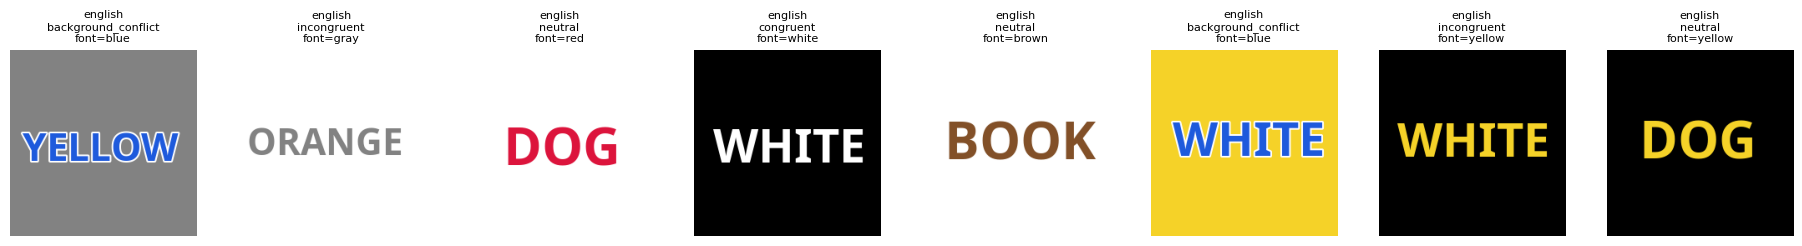

In [8]:
# ============================================================
# Experiment 1: Generate main English Stroop dataset
# ============================================================

if RUN_DATA_GENERATION:
    main_english_df = generate_stroop_dataset(
        languages=["english"],
        conditions=CONDITIONS,
        num_per_language_condition=MAIN_NUM_PER_CONDITION,
        out_dir=MAIN_STROOP_DIR,
        dataset_name="main_english_stroop",
    )
else:
    main_english_df = pd.read_csv(MAIN_STROOP_DIR / "main_english_stroop_metadata.csv")

display(main_english_df.head())

print("Main English Stroop dataset size:", len(main_english_df))
display(main_english_df.groupby(["language", "condition"]).size().reset_index(name="num_images"))

show_random_samples(main_english_df, n=8)

# Experiment 2: Prompt robustness

This experiment uses the **same main English Stroop images**.

It does not create new images. Instead, each image is evaluated using several prompt templates.

## Why this matters

The original prompt, `"the text is written in {color}"`, may be ambiguous.

It could mean:

- the font/ink color is `{color}`
- the text is written in a language/script
- the word meaning is `{color}`

So this notebook tests several levels of prompt explicitness:

| Prompt style | Purpose |
|---|---|
| Vague | See if the model relies on broad color association |
| Ambiguous | Match the original setup |
| Exact | Directly ask for ink/font color |
| Descriptive | Explicitly tell the model to ignore word meaning/background |
| Control | Intentionally test word/background cue alignment |

## Dataset size

Full mode:

- Unique images = 40,000
- Prompt templates = 12
- Prompt evaluations = 40,000 × 12 = 480,000 image-prompt-template evaluations

Each evaluation still compares against all 10 color candidates.

In [9]:
# ============================================================
# 5. CLIP loading and zero-shot evaluation helpers
# ============================================================

if RUN_CLIP_EVAL:
    import clip

    device = "cuda" if torch.cuda.is_available() else "cpu"
    print("Using device:", device)

    CLIP_MODEL_NAME = "ViT-B/16"
    clip_model, clip_preprocess = clip.load(CLIP_MODEL_NAME, device=device)
    clip_model.eval()

    print("Loaded CLIP model:", CLIP_MODEL_NAME)
else:
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print("Skipping CLIP load.")


class ImageDatasetForCLIP(Dataset):
    def __init__(self, df: pd.DataFrame):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        image_tensor = clip_preprocess(image)
        return image_tensor, idx


def categorize_color_prediction(row) -> str:
    """Classify prediction into correct font color, word bias, background bias, or other error."""

    pred = row["pred_color"]
    font = row["font_color"]
    word = row.get("word_color", "")
    bg = row.get("background_color", "")

    if pred == font:
        return "correct_font_color"

    if isinstance(word, str) and len(word) > 0 and pred == word:
        return "word_bias"

    if isinstance(bg, str) and len(bg) > 0 and pred == bg:
        return "background_bias"

    return "other_error"


def evaluate_clip_color_prompt(
    df: pd.DataFrame,
    prompt_key: str,
    batch_size: int = 128,
) -> pd.DataFrame:
    """
    Evaluate CLIP for font-color prediction.

    For one prompt template, create 10 candidate prompts:
        template(red), template(blue), ..., template(white)

    The predicted color is the candidate with the highest image-text similarity.
    """

    if not RUN_CLIP_EVAL:
        raise RuntimeError("RUN_CLIP_EVAL is False.")

    prompt_info = PROMPT_TEMPLATES[prompt_key]
    template = prompt_info["template"]
    candidate_prompts = [template.format(color=color) for color in COLOR_NAMES]

    text_tokens = clip.tokenize(candidate_prompts).to(device)

    with torch.no_grad():
        text_features = clip_model.encode_text(text_tokens)
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)

    dataset = ImageDatasetForCLIP(df)
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=(device == "cuda"),
    )

    records = []

    for image_batch, indices in tqdm(loader, desc=f"CLIP eval: {prompt_key}"):
        image_batch = image_batch.to(device)

        with torch.no_grad():
            image_features = clip_model.encode_image(image_batch)
            image_features = image_features / image_features.norm(dim=-1, keepdim=True)
            similarity = image_features @ text_features.T

        pred_indices = similarity.argmax(dim=1).detach().cpu().numpy()
        pred_scores = similarity.max(dim=1).values.detach().cpu().numpy()

        for local_i, row_idx in enumerate(indices.numpy()):
            base = df.iloc[row_idx].to_dict()
            pred_color = COLOR_NAMES[int(pred_indices[local_i])]
            base["prompt_key"] = prompt_key
            base["prompt_style"] = prompt_info["style"]
            base["prompt_template"] = template
            base["pred_color"] = pred_color
            base["clip_score"] = float(pred_scores[local_i])
            records.append(base)

    result_df = pd.DataFrame(records)
    result_df["error_type"] = result_df.apply(categorize_color_prediction, axis=1)
    result_df["is_correct"] = result_df["pred_color"] == result_df["font_color"]

    return result_df


def summarize_color_predictions(pred_df: pd.DataFrame) -> pd.DataFrame:
    """Create a compact summary by prompt/language/condition."""

    group_cols = ["prompt_key", "prompt_style", "language", "condition"]
    rows = []

    for keys, group in pred_df.groupby(group_cols):
        prompt_key, prompt_style, language, condition = keys
        n = len(group)
        rows.append({
            "prompt_key": prompt_key,
            "prompt_style": prompt_style,
            "language": language,
            "condition": condition,
            "num_images": n,
            "accuracy": float((group["error_type"] == "correct_font_color").mean()),
            "word_bias_rate": float((group["error_type"] == "word_bias").mean()),
            "background_bias_rate": float((group["error_type"] == "background_bias").mean()),
            "other_error_rate": float((group["error_type"] == "other_error").mean()),
        })

    return pd.DataFrame(rows)

Using device: cuda


100%|███████████████████████████████████████| 335M/335M [00:05<00:00, 61.6MiB/s]


Loaded CLIP model: ViT-B/16


In [10]:
# ============================================================
# Experiment 1 baseline CLIP evaluation on main English dataset
# ============================================================

MAIN_RESULTS_DIR = RESULTS_DIR / "experiment_1_main_english_stroop"
MAIN_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

if RUN_CLIP_EVAL:
    main_clip_predictions_df = evaluate_clip_color_prompt(
        df=main_english_df,
        prompt_key=MAIN_COLOR_PROMPT_KEY,
        batch_size=128,
    )

    main_pred_path = MAIN_RESULTS_DIR / "clip_main_english_predictions.csv"
    main_summary_path = MAIN_RESULTS_DIR / "clip_main_english_summary.csv"

    main_clip_predictions_df.to_csv(main_pred_path, index=False)
    main_summary_df = summarize_color_predictions(main_clip_predictions_df)
    main_summary_df.to_csv(main_summary_path, index=False)

    print("Saved:", main_pred_path)
    print("Saved:", main_summary_path)
    display(main_summary_df)

CLIP eval: exact_ink_color:   0%|          | 0/313 [00:00<?, ?it/s]

Saved: /content/stroop_multilingual_full_benchmark/results/experiment_1_main_english_stroop/clip_main_english_predictions.csv
Saved: /content/stroop_multilingual_full_benchmark/results/experiment_1_main_english_stroop/clip_main_english_summary.csv


,prompt_key,prompt_style,language,condition,num_images,accuracy,word_bias_rate,background_bias_rate,other_error_rate
0,exact_ink_color,exact,english,background_conflict,10000,0.0523,0.8896,0.0581,0.0000
1,exact_ink_color,exact,english,congruent,10000,1.0000,0.0000,0.0000,0.0000
2,exact_ink_color,exact,english,incongruent,10000,0.0828,0.9172,0.0000,0.0000
3,exact_ink_color,exact,english,neutral,10000,0.7974,0.0000,0.0237,0.1789


In [11]:
# ============================================================
# Experiment 2 prompt robustness evaluation
# ============================================================

PROMPT_RESULTS_DIR = RESULTS_DIR / "experiment_2_prompt_robustness"
PROMPT_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

if RUN_CLIP_EVAL:
    prompt_result_frames = []

    for prompt_key in PROMPT_TEMPLATES.keys():
        result_df = evaluate_clip_color_prompt(
            df=main_english_df,
            prompt_key=prompt_key,
            batch_size=128,
        )
        prompt_result_frames.append(result_df)

    prompt_results_df = pd.concat(prompt_result_frames, ignore_index=True)
    prompt_summary_df = summarize_color_predictions(prompt_results_df)

    prompt_results_path = PROMPT_RESULTS_DIR / "clip_prompt_robustness_predictions.csv"
    prompt_summary_path = PROMPT_RESULTS_DIR / "clip_prompt_robustness_summary.csv"

    prompt_results_df.to_csv(prompt_results_path, index=False)
    prompt_summary_df.to_csv(prompt_summary_path, index=False)

    print("Saved:", prompt_results_path)
    print("Saved:", prompt_summary_path)

    display(prompt_summary_df.sort_values(["prompt_style", "prompt_key", "condition"]))

CLIP eval: vague_minimal_color:   0%|          | 0/313 [00:00<?, ?it/s]

CLIP eval: vague_colored_word:   0%|          | 0/313 [00:00<?, ?it/s]

CLIP eval: original_ambiguous_written_in:   0%|          | 0/313 [00:00<?, ?it/s]

CLIP eval: exact_ink_color:   0%|          | 0/313 [00:00<?, ?it/s]

CLIP eval: exact_font_color:   0%|          | 0/313 [00:00<?, ?it/s]

...

CLIP eval: very_descriptive_ignore_all_distractors:   0%|          | 0/313 [00:00<?, ?it/s]

CLIP eval: control_word_oriented:   0%|          | 0/313 [00:00<?, ?it/s]

CLIP eval: control_background:   0%|          | 0/313 [00:00<?, ?it/s]

Saved: /content/stroop_multilingual_full_benchmark/results/experiment_2_prompt_robustness/clip_prompt_robustness_predictions.csv
Saved: /content/stroop_multilingual_full_benchmark/results/experiment_2_prompt_robustness/clip_prompt_robustness_summary.csv


,prompt_key,prompt_style,language,condition,num_images,accuracy,word_bias_rate,background_bias_rate,other_error_rate
28,original_ambiguous_written_in,ambiguous,english,background_conflict,10000,0.0074,0.9840,0.0086,0.0000
29,original_ambiguous_written_in,ambiguous,english,congruent,10000,1.0000,0.0000,0.0000,0.0000
30,original_ambiguous_written_in,ambiguous,english,incongruent,10000,0.0172,0.9828,0.0000,0.0000
31,original_ambiguous_written_in,ambiguous,english,neutral,10000,0.7312,0.0000,0.2672,0.0016
0,control_background,control,english,background_conflict,10000,0.0017,0.9915,0.0068,0.0000
1,control_background,control,english,congruent,10000,1.0000,0.0000,0.0000,0.0000
2,control_background,control,english,incongruent,10000,0.0031,0.9969,0.0000,0.0000
3,control_background,control,english,neutral,10000,0.8178,0.0000,0.0744,0.1078
4,control_word_oriented,control,english,background_conflict,10000,0.0000,1.0000,0.0000,0.0000
5,control_word_oriented,control,english,congruent,10000,1.0000,0.0000,0.0000,0.0000


condition,prompt_key,prompt_style,background_conflict,incongruent
0,control_background,control,0.9915,0.9969
1,control_word_oriented,control,1.0000,1.0000
2,descriptive_ignore_word,descriptive,0.8798,0.8952
3,descriptive_not_background,descriptive,0.9266,0.9459
4,exact_font_color,exact,0.9450,0.9454
5,exact_ink_color,exact,0.8896,0.9172
6,exact_letters_color,exact,0.9712,0.9741
7,original_ambiguous_written_in,ambiguous,0.9840,0.9828
8,vague_colored_word,vague,0.9999,1.0000
9,vague_minimal_color,vague,0.9973,1.0000


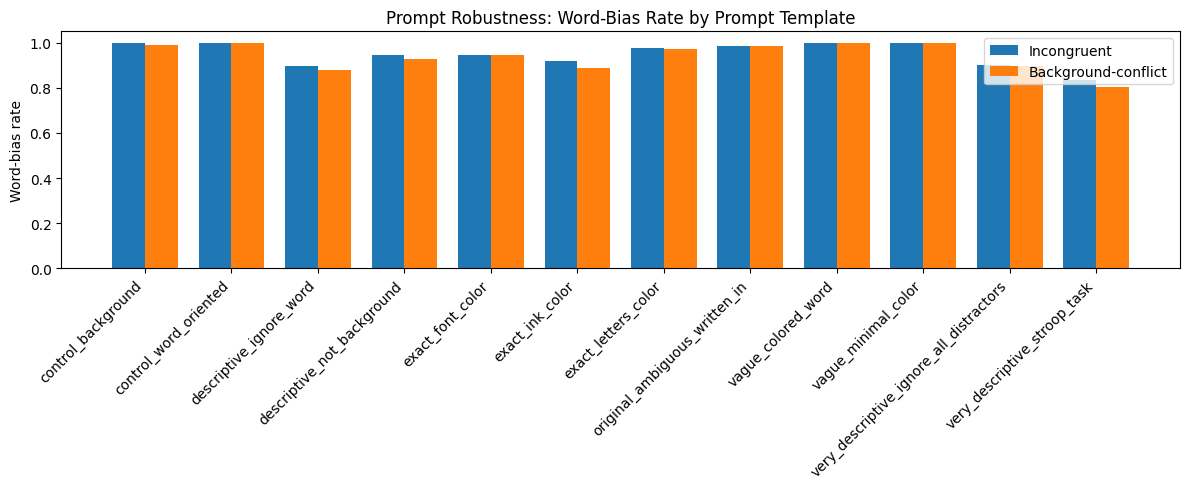

Saved plot: /content/stroop_multilingual_full_benchmark/results/experiment_2_prompt_robustness/prompt_robustness_word_bias_by_prompt.png


In [12]:
# ============================================================
# Prompt robustness visualization
# ============================================================

if RUN_CLIP_EVAL:
    plot_df = prompt_summary_df[
        prompt_summary_df["condition"].isin(["incongruent", "background_conflict"])
    ].copy()

    # Focus on word-bias rate by prompt.
    pivot = plot_df.pivot_table(
        index=["prompt_key", "prompt_style"],
        columns="condition",
        values="word_bias_rate",
        aggfunc="mean"
    ).reset_index()

    display(pivot)

    plt.figure(figsize=(12, 5))
    x = np.arange(len(pivot))
    width = 0.38

    plt.bar(x - width/2, pivot.get("incongruent", 0), width, label="Incongruent")
    plt.bar(x + width/2, pivot.get("background_conflict", 0), width, label="Background-conflict")

    plt.xticks(x, pivot["prompt_key"], rotation=45, ha="right")
    plt.ylabel("Word-bias rate")
    plt.title("Prompt Robustness: Word-Bias Rate by Prompt Template")
    plt.legend()
    plt.tight_layout()

    prompt_plot_path = PROMPT_RESULTS_DIR / "prompt_robustness_word_bias_by_prompt.png"
    plt.savefig(prompt_plot_path, dpi=200, bbox_inches="tight")
    plt.show()

    print("Saved plot:", prompt_plot_path)

# Experiment 3: Standard text-meaning recognition control

## Purpose

This experiment is **not** about font color.

It checks whether the model can recognize the written word in a clean setting.

## Setup

- black text
- white background
- no color conflict
- no background conflict
- task = recognize the word meaning or written word

## Dataset size

Full mode:

- 4 languages
- 20 word classes per language
  - 10 color words
  - 10 neutral object words
- 250 samples per word

Total:

**4 × 20 × 250 = 20,000 images**

| Language | Color-word images | Neutral-word images | Total |
|---|---:|---:|---:|
| English | 2,500 | 2,500 | 5,000 |
| Chinese | 2,500 | 2,500 | 5,000 |
| Hindi | 2,500 | 2,500 | 5,000 |
| Arabic | 2,500 | 2,500 | 5,000 |
| Total | 10,000 | 10,000 | 20,000 |

This control helps interpret the multilingual Stroop result. If a model cannot recognize a script, then that script should create less word interference.

Generating text meaning: english-red:   0%|          | 0/250 [00:00<?, ?it/s]

Generating text meaning: english-blue:   0%|          | 0/250 [00:00<?, ?it/s]

Generating text meaning: english-green:   0%|          | 0/250 [00:00<?, ?it/s]

Generating text meaning: english-yellow:   0%|          | 0/250 [00:00<?, ?it/s]

Generating text meaning: english-orange:   0%|          | 0/250 [00:00<?, ?it/s]

...

Generating text meaning: arabic-music:   0%|          | 0/250 [00:00<?, ?it/s]

Saved metadata: /content/stroop_multilingual_full_benchmark/data/text_meaning_control_20k/text_meaning_control_metadata.csv
Total images: 20000


,image_id,image_path,mask_path,dataset,language,condition,word_category,canonical_label,script_word,font_color,background_color
0,text_meaning_control_english_red_00000,/content/stroop_multilingual_full_benchmark/da...,/content/stroop_multilingual_full_benchmark/da...,text_meaning_control,english,black_text_white_background,color_word,red,RED,black,white
1,text_meaning_control_english_red_00001,/content/stroop_multilingual_full_benchmark/da...,/content/stroop_multilingual_full_benchmark/da...,text_meaning_control,english,black_text_white_background,color_word,red,RED,black,white
2,text_meaning_control_english_red_00002,/content/stroop_multilingual_full_benchmark/da...,/content/stroop_multilingual_full_benchmark/da...,text_meaning_control,english,black_text_white_background,color_word,red,RED,black,white
3,text_meaning_control_english_red_00003,/content/stroop_multilingual_full_benchmark/da...,/content/stroop_multilingual_full_benchmark/da...,text_meaning_control,english,black_text_white_background,color_word,red,RED,black,white
4,text_meaning_control_english_red_00004,/content/stroop_multilingual_full_benchmark/da...,/content/stroop_multilingual_full_benchmark/da...,text_meaning_control,english,black_text_white_background,color_word,red,RED,black,white


Text meaning control dataset size: 20000


,language,word_category,num_images
0,arabic,color_word,2500
1,arabic,neutral_word,2500
2,chinese,color_word,2500
3,chinese,neutral_word,2500
4,english,color_word,2500
5,english,neutral_word,2500
6,hindi,color_word,2500
7,hindi,neutral_word,2500


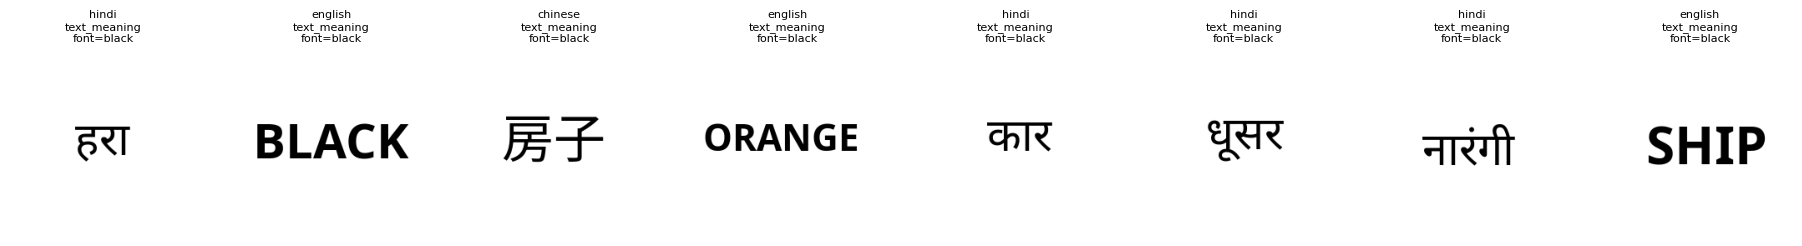

In [13]:
# ============================================================
# Experiment 3: Text-meaning recognition control generation
# ============================================================

def generate_text_meaning_control_dataset(
    languages: List[str],
    samples_per_word: int,
    out_dir: Path,
    dataset_name: str = "text_meaning_control",
) -> pd.DataFrame:
    """Generate black text on white background for text recognition control."""

    metadata_path = out_dir / f"{dataset_name}_metadata.csv"
    if metadata_path.exists():
        print("Metadata already exists. Loading:", metadata_path)
        return pd.read_csv(metadata_path)

    image_dir = out_dir / "images"
    mask_dir = out_dir / "masks"
    image_dir.mkdir(parents=True, exist_ok=True)
    mask_dir.mkdir(parents=True, exist_ok=True)

    records = []

    for language in languages:
        # Build 20 words: 10 color words + 10 neutral words
        word_items = []

        for canonical_color, script_word in COLOR_WORDS_BY_LANGUAGE[language].items():
            word_items.append({
                "word_category": "color_word",
                "canonical_label": canonical_color,
                "script_word": script_word,
            })

        for neutral_label, script_word in NEUTRAL_WORDS_BY_LANGUAGE[language].items():
            word_items.append({
                "word_category": "neutral_word",
                "canonical_label": neutral_label,
                "script_word": script_word,
            })

        for item in word_items:
            for i in tqdm(
                range(samples_per_word),
                desc=f"Generating text meaning: {language}-{item['canonical_label']}"
            ):
                image_id = f"{dataset_name}_{language}_{item['canonical_label']}_{i:05d}"

                image, mask = draw_text_image(
                    word=item["script_word"],
                    font_color="black",
                    background_color="white",
                    language=language,
                    image_size=IMAGE_SIZE,
                )

                image_path = image_dir / f"{image_id}.png"
                mask_path = mask_dir / f"{image_id}_mask.png"
                save_image_and_mask(image, mask, image_path, mask_path)

                records.append({
                    "image_id": image_id,
                    "image_path": str(image_path),
                    "mask_path": str(mask_path),
                    "dataset": "text_meaning_control",
                    "language": language,
                    "condition": "black_text_white_background",
                    "word_category": item["word_category"],
                    "canonical_label": item["canonical_label"],
                    "script_word": item["script_word"],
                    "font_color": "black",
                    "background_color": "white",
                })

    df = pd.DataFrame(records)
    df.to_csv(metadata_path, index=False)
    print("Saved metadata:", metadata_path)
    print("Total images:", len(df))

    return df


if RUN_DATA_GENERATION:
    text_meaning_df = generate_text_meaning_control_dataset(
        languages=LANGUAGES,
        samples_per_word=TEXT_MEANING_SAMPLES_PER_WORD,
        out_dir=TEXT_MEANING_DIR,
    )
else:
    text_meaning_df = pd.read_csv(TEXT_MEANING_DIR / "text_meaning_control_metadata.csv")

display(text_meaning_df.head())
print("Text meaning control dataset size:", len(text_meaning_df))
display(text_meaning_df.groupby(["language", "word_category"]).size().reset_index(name="num_images"))

show_random_samples(
    text_meaning_df.rename(columns={"canonical_label": "label"}).assign(condition="text_meaning"),
    n=8
)

In [14]:
# ============================================================
# Experiment 3: CLIP text-meaning recognition evaluation
# ============================================================

TEXT_MEANING_RESULTS_DIR = RESULTS_DIR / "experiment_3_text_meaning_control"
TEXT_MEANING_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

TEXT_MEANING_LABELS = COLOR_NAMES + NEUTRAL_LABELS


def evaluate_clip_text_meaning(
    df: pd.DataFrame,
    mode: str = "script_match",
    batch_size: int = 128,
) -> pd.DataFrame:
    """
    Evaluate CLIP on text-meaning control.

    Modes:
    - script_match:
        Candidate prompts contain the same script as the image.
        Example Chinese candidate: 'the word says 红色'

    - english_semantic:
        Candidate prompts use English semantic labels.
        Example Chinese image 红色 is matched against 'the written word means red'
    """

    if not RUN_CLIP_EVAL:
        raise RuntimeError("RUN_CLIP_EVAL is False.")

    all_records = []

    for language, lang_df in df.groupby("language"):
        label_to_script_word = {}

        for c in COLOR_NAMES:
            label_to_script_word[c] = COLOR_WORDS_BY_LANGUAGE[language][c]
        for n in NEUTRAL_LABELS:
            label_to_script_word[n] = NEUTRAL_WORDS_BY_LANGUAGE[language][n]

        if mode == "script_match":
            candidate_prompts = [
                f"the word says {label_to_script_word[label]}"
                for label in TEXT_MEANING_LABELS
            ]
        elif mode == "english_semantic":
            candidate_prompts = [
                f"the written word means {label}"
                for label in TEXT_MEANING_LABELS
            ]
        else:
            raise ValueError("mode must be 'script_match' or 'english_semantic'.")

        text_tokens = clip.tokenize(candidate_prompts).to(device)

        with torch.no_grad():
            text_features = clip_model.encode_text(text_tokens)
            text_features = text_features / text_features.norm(dim=-1, keepdim=True)

        dataset = ImageDatasetForCLIP(lang_df)
        loader = DataLoader(
            dataset,
            batch_size=batch_size,
            shuffle=False,
            num_workers=0,
            pin_memory=(device == "cuda"),
        )

        for image_batch, indices in tqdm(loader, desc=f"CLIP text meaning: {language}-{mode}"):
            image_batch = image_batch.to(device)

            with torch.no_grad():
                image_features = clip_model.encode_image(image_batch)
                image_features = image_features / image_features.norm(dim=-1, keepdim=True)
                similarity = image_features @ text_features.T

            pred_indices = similarity.argmax(dim=1).detach().cpu().numpy()
            pred_scores = similarity.max(dim=1).values.detach().cpu().numpy()

            for local_i, row_idx in enumerate(indices.numpy()):
                base = lang_df.iloc[row_idx].to_dict()
                pred_label = TEXT_MEANING_LABELS[int(pred_indices[local_i])]
                base["eval_mode"] = mode
                base["pred_label"] = pred_label
                base["clip_score"] = float(pred_scores[local_i])
                base["is_correct"] = pred_label == base["canonical_label"]
                all_records.append(base)

    return pd.DataFrame(all_records)


if RUN_CLIP_EVAL:
    text_meaning_script_df = evaluate_clip_text_meaning(
        text_meaning_df,
        mode="script_match",
        batch_size=128,
    )

    text_meaning_semantic_df = evaluate_clip_text_meaning(
        text_meaning_df,
        mode="english_semantic",
        batch_size=128,
    )

    text_meaning_results_df = pd.concat(
        [text_meaning_script_df, text_meaning_semantic_df],
        ignore_index=True
    )

    text_meaning_results_path = TEXT_MEANING_RESULTS_DIR / "clip_text_meaning_predictions.csv"
    text_meaning_summary_path = TEXT_MEANING_RESULTS_DIR / "clip_text_meaning_summary.csv"

    text_meaning_results_df.to_csv(text_meaning_results_path, index=False)

    text_meaning_summary_df = (
        text_meaning_results_df
        .groupby(["eval_mode", "language", "word_category"])
        .agg(
            num_images=("image_id", "count"),
            accuracy=("is_correct", "mean")
        )
        .reset_index()
    )

    text_meaning_summary_df.to_csv(text_meaning_summary_path, index=False)

    print("Saved:", text_meaning_results_path)
    print("Saved:", text_meaning_summary_path)
    display(text_meaning_summary_df)

CLIP text meaning: arabic-script_match:   0%|          | 0/40 [00:00<?, ?it/s]

CLIP text meaning: chinese-script_match:   0%|          | 0/40 [00:00<?, ?it/s]

CLIP text meaning: english-script_match:   0%|          | 0/40 [00:00<?, ?it/s]

CLIP text meaning: hindi-script_match:   0%|          | 0/40 [00:00<?, ?it/s]

CLIP text meaning: arabic-english_semantic:   0%|          | 0/40 [00:00<?, ?it/s]

CLIP text meaning: chinese-english_semantic:   0%|          | 0/40 [00:00<?, ?it/s]

CLIP text meaning: english-english_semantic:   0%|          | 0/40 [00:00<?, ?it/s]

CLIP text meaning: hindi-english_semantic:   0%|          | 0/40 [00:00<?, ?it/s]

Saved: /content/stroop_multilingual_full_benchmark/results/experiment_3_text_meaning_control/clip_text_meaning_predictions.csv
Saved: /content/stroop_multilingual_full_benchmark/results/experiment_3_text_meaning_control/clip_text_meaning_summary.csv


,eval_mode,language,word_category,num_images,accuracy
0,english_semantic,arabic,color_word,2500,0.1084
1,english_semantic,arabic,neutral_word,2500,0.0000
2,english_semantic,chinese,color_word,2500,0.1568
3,english_semantic,chinese,neutral_word,2500,0.0000
4,english_semantic,english,color_word,2500,1.0000
5,english_semantic,english,neutral_word,2500,1.0000
6,english_semantic,hindi,color_word,2500,0.1000
7,english_semantic,hindi,neutral_word,2500,0.0000
8,script_match,arabic,color_word,2500,0.1000
9,script_match,arabic,neutral_word,2500,0.0000


# Experiment 4: Multilingual Stroop dataset

This experiment tests whether word bias changes across scripts.

## Purpose

The semantic labels stay the same, but the written text changes script.

Example:

| Semantic color | English | Chinese | Hindi | Arabic |
|---|---|---|---|---|
| red | RED | 红色 | लाल | أحمر |

If the model can read a script, the word meaning may interfere more strongly.

## Dataset size

Full mode:

- 4 languages
- 4 conditions
- 5,000 images per language per condition

Total:

**4 × 4 × 5,000 = 80,000 images**

| Language | Congruent | Incongruent | Neutral | Background-conflict | Total |
|---|---:|---:|---:|---:|---:|
| English | 5,000 | 5,000 | 5,000 | 5,000 | 20,000 |
| Chinese | 5,000 | 5,000 | 5,000 | 5,000 | 20,000 |
| Hindi | 5,000 | 5,000 | 5,000 | 5,000 | 20,000 |
| Arabic | 5,000 | 5,000 | 5,000 | 5,000 | 20,000 |
| Total | 20,000 | 20,000 | 20,000 | 20,000 | 80,000 |

Generating multilingual_stroop: english-congruent:   0%|          | 0/5000 [00:00<?, ?it/s]

Generating multilingual_stroop: english-incongruent:   0%|          | 0/5000 [00:00<?, ?it/s]

Generating multilingual_stroop: english-neutral:   0%|          | 0/5000 [00:00<?, ?it/s]

Generating multilingual_stroop: english-background_conflict:   0%|          | 0/5000 [00:00<?, ?it/s]

Generating multilingual_stroop: chinese-congruent:   0%|          | 0/5000 [00:00<?, ?it/s]

...

Generating multilingual_stroop: arabic-background_conflict:   0%|          | 0/5000 [00:00<?, ?it/s]

Saved metadata: /content/stroop_multilingual_full_benchmark/data/multilingual_stroop_80k/multilingual_stroop_metadata.csv
Total images: 80000


,image_id,image_path,mask_path,dataset,language,condition,word,word_color,font_color,background_color,label,dataset_name
0,multilingual_stroop_english_congruent_000000,/content/stroop_multilingual_full_benchmark/da...,/content/stroop_multilingual_full_benchmark/da...,stroop,english,congruent,ORANGE,orange,orange,black,orange,multilingual_stroop
1,multilingual_stroop_english_congruent_000001,/content/stroop_multilingual_full_benchmark/da...,/content/stroop_multilingual_full_benchmark/da...,stroop,english,congruent,WHITE,white,white,black,white,multilingual_stroop
2,multilingual_stroop_english_congruent_000002,/content/stroop_multilingual_full_benchmark/da...,/content/stroop_multilingual_full_benchmark/da...,stroop,english,congruent,WHITE,white,white,black,white,multilingual_stroop
3,multilingual_stroop_english_congruent_000003,/content/stroop_multilingual_full_benchmark/da...,/content/stroop_multilingual_full_benchmark/da...,stroop,english,congruent,GREEN,green,green,white,green,multilingual_stroop
4,multilingual_stroop_english_congruent_000004,/content/stroop_multilingual_full_benchmark/da...,/content/stroop_multilingual_full_benchmark/da...,stroop,english,congruent,PURPLE,purple,purple,white,purple,multilingual_stroop


Multilingual Stroop dataset size: 80000


,language,condition,num_images
0,arabic,background_conflict,5000
1,arabic,congruent,5000
2,arabic,incongruent,5000
3,arabic,neutral,5000
4,chinese,background_conflict,5000
5,chinese,congruent,5000
6,chinese,incongruent,5000
7,chinese,neutral,5000
8,english,background_conflict,5000
9,english,congruent,5000


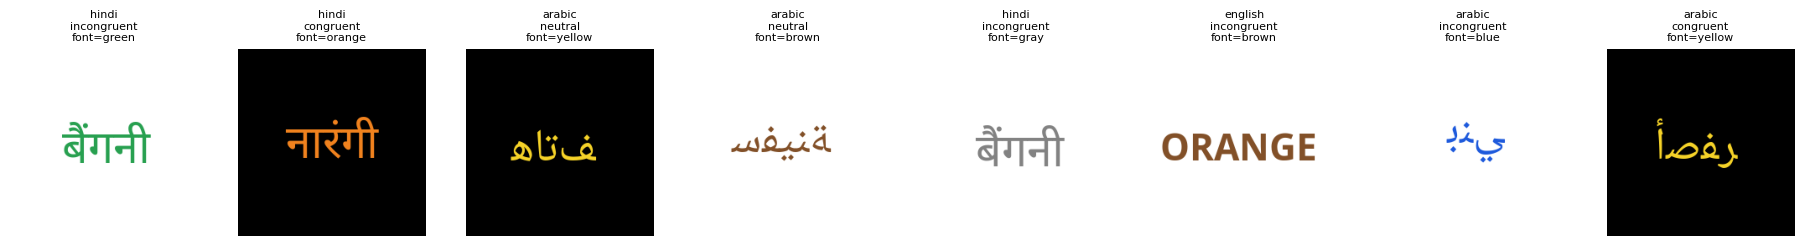

In [15]:
# ============================================================
# Experiment 4: Generate multilingual Stroop dataset
# ============================================================

if RUN_DATA_GENERATION:
    multilingual_stroop_df = generate_stroop_dataset(
        languages=LANGUAGES,
        conditions=CONDITIONS,
        num_per_language_condition=MULTILINGUAL_NUM_PER_LANGUAGE_CONDITION,
        out_dir=MULTILINGUAL_STROOP_DIR,
        dataset_name="multilingual_stroop",
    )
else:
    multilingual_stroop_df = pd.read_csv(MULTILINGUAL_STROOP_DIR / "multilingual_stroop_metadata.csv")

display(multilingual_stroop_df.head())

print("Multilingual Stroop dataset size:", len(multilingual_stroop_df))
display(multilingual_stroop_df.groupby(["language", "condition"]).size().reset_index(name="num_images"))

show_random_samples(multilingual_stroop_df, n=8)

In [16]:
# ============================================================
# Experiment 4: CLIP multilingual Stroop evaluation
# ============================================================

MULTILINGUAL_RESULTS_DIR = RESULTS_DIR / "experiment_4_multilingual_stroop"
MULTILINGUAL_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

if RUN_CLIP_EVAL:
    # Use exact ink-color prompt for the main multilingual comparison.
    multilingual_clip_predictions_df = evaluate_clip_color_prompt(
        df=multilingual_stroop_df,
        prompt_key=MAIN_COLOR_PROMPT_KEY,
        batch_size=128,
    )

    multilingual_predictions_path = MULTILINGUAL_RESULTS_DIR / "clip_multilingual_stroop_predictions.csv"
    multilingual_summary_path = MULTILINGUAL_RESULTS_DIR / "clip_multilingual_stroop_summary.csv"

    multilingual_clip_predictions_df.to_csv(multilingual_predictions_path, index=False)
    multilingual_summary_df = summarize_color_predictions(multilingual_clip_predictions_df)
    multilingual_summary_df.to_csv(multilingual_summary_path, index=False)

    print("Saved:", multilingual_predictions_path)
    print("Saved:", multilingual_summary_path)
    display(multilingual_summary_df)

CLIP eval: exact_ink_color:   0%|          | 0/625 [00:00<?, ?it/s]

Saved: /content/stroop_multilingual_full_benchmark/results/experiment_4_multilingual_stroop/clip_multilingual_stroop_predictions.csv
Saved: /content/stroop_multilingual_full_benchmark/results/experiment_4_multilingual_stroop/clip_multilingual_stroop_summary.csv


,prompt_key,prompt_style,language,condition,num_images,accuracy,word_bias_rate,background_bias_rate,other_error_rate
0,exact_ink_color,exact,arabic,background_conflict,5000,0.2092,0.0014,0.7760,0.0134
1,exact_ink_color,exact,arabic,congruent,5000,0.7832,0.0000,0.1184,0.0984
2,exact_ink_color,exact,arabic,incongruent,5000,0.7914,0.0302,0.0906,0.0878
3,exact_ink_color,exact,arabic,neutral,5000,0.8046,0.0000,0.0836,0.1118
4,exact_ink_color,exact,chinese,background_conflict,5000,0.2762,0.0028,0.7098,0.0112
5,exact_ink_color,exact,chinese,congruent,5000,0.7990,0.0000,0.0582,0.1428
6,exact_ink_color,exact,chinese,incongruent,5000,0.8082,0.0208,0.0810,0.0900
7,exact_ink_color,exact,chinese,neutral,5000,0.7960,0.0000,0.0880,0.1160
8,exact_ink_color,exact,english,background_conflict,5000,0.0512,0.8858,0.0630,0.0000
9,exact_ink_color,exact,english,congruent,5000,1.0000,0.0000,0.0000,0.0000


condition,language,background_conflict,incongruent
0,arabic,0.0014,0.0302
1,chinese,0.0028,0.0208
2,english,0.8858,0.9170
3,hindi,0.0008,0.0326


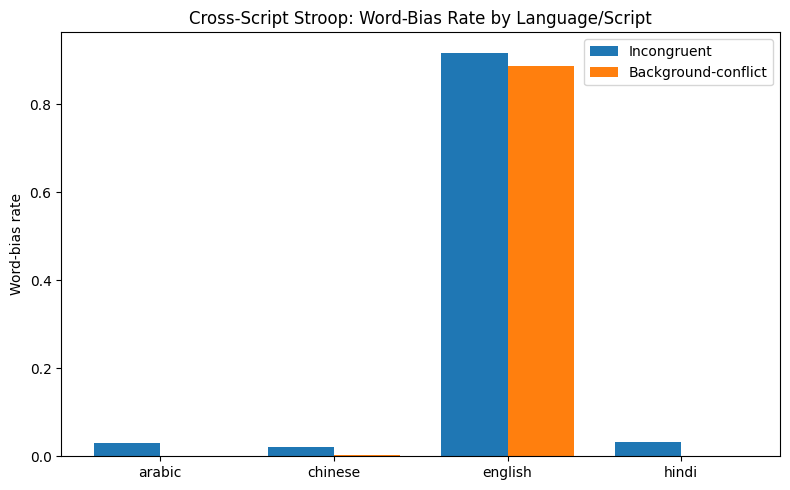

Saved plot: /content/stroop_multilingual_full_benchmark/results/experiment_4_multilingual_stroop/cross_script_word_bias_plot.png


In [17]:
# ============================================================
# Multilingual visualization
# ============================================================

if RUN_CLIP_EVAL:
    plot_df = multilingual_summary_df[
        multilingual_summary_df["condition"].isin(["incongruent", "background_conflict"])
    ].copy()

    pivot = plot_df.pivot_table(
        index="language",
        columns="condition",
        values="word_bias_rate",
        aggfunc="mean"
    ).reset_index()

    display(pivot)

    plt.figure(figsize=(8, 5))
    x = np.arange(len(pivot))
    width = 0.38

    plt.bar(x - width/2, pivot.get("incongruent", 0), width, label="Incongruent")
    plt.bar(x + width/2, pivot.get("background_conflict", 0), width, label="Background-conflict")

    plt.xticks(x, pivot["language"])
    plt.ylabel("Word-bias rate")
    plt.title("Cross-Script Stroop: Word-Bias Rate by Language/Script")
    plt.legend()
    plt.tight_layout()

    cross_script_plot_path = MULTILINGUAL_RESULTS_DIR / "cross_script_word_bias_plot.png"
    plt.savefig(cross_script_plot_path, dpi=200, bbox_inches="tight")
    plt.show()

    print("Saved plot:", cross_script_plot_path)

# Experiment 5: Model comparison with Qwen and Llama Vision

CLIP can be run over the full dataset because it is efficient.

Instruction-following VLMs such as Qwen2.5-VL and Llama Vision are slower. For them, this notebook starts with a **balanced subset**.

## Recommended full-subset setting

For Qwen/Llama:

- 4 languages
- 4 conditions
- 1,000 images per language per condition

Total per model:

**4 × 4 × 1,000 = 16,000 images per model**

This is large enough to compare behavior but more manageable than evaluating all 80,000 multilingual images.

You can later increase:

```python
VLM_SUBSET_PER_LANGUAGE_CONDITION = 2000
```

for 32,000 images per model.

In [18]:
# ============================================================
# Experiment 5: Balanced subset helper for Qwen/Llama
# ============================================================

def make_balanced_subset(
    df: pd.DataFrame,
    group_cols: List[str],
    n_per_group: int,
    seed: int = SEED,
) -> pd.DataFrame:
    """Sample up to n_per_group examples from each group."""

    frames = []
    for keys, group in df.groupby(group_cols):
        sample_n = min(n_per_group, len(group))
        frames.append(group.sample(n=sample_n, random_state=seed))

    return pd.concat(frames, ignore_index=True)


vlm_eval_subset_df = make_balanced_subset(
    multilingual_stroop_df,
    group_cols=["language", "condition"],
    n_per_group=VLM_SUBSET_PER_LANGUAGE_CONDITION,
)

vlm_subset_path = RESULTS_DIR / "vlm_balanced_multilingual_subset.csv"
vlm_eval_subset_df.to_csv(vlm_subset_path, index=False)

print("Saved VLM subset:", vlm_subset_path)
print("VLM subset size:", len(vlm_eval_subset_df))
display(vlm_eval_subset_df.groupby(["language", "condition"]).size().reset_index(name="num_images"))

Saved VLM subset: /content/stroop_multilingual_full_benchmark/results/vlm_balanced_multilingual_subset.csv
VLM subset size: 16000


,language,condition,num_images
0,arabic,background_conflict,1000
1,arabic,congruent,1000
2,arabic,incongruent,1000
3,arabic,neutral,1000
4,chinese,background_conflict,1000
5,chinese,congruent,1000
6,chinese,incongruent,1000
7,chinese,neutral,1000
8,english,background_conflict,1000
9,english,congruent,1000


In [19]:
# ============================================================
# Generic answer parser for instruction-following VLMs
# ============================================================

def parse_color_answer(answer: str) -> str:
    """Parse one of the 10 canonical color names from a generated answer."""

    if not isinstance(answer, str):
        return ""

    text = answer.lower().strip()

    # Normalize common spelling variants.
    text = text.replace("grey", "gray")

    for color in COLOR_NAMES:
        pattern = r"\b" + re.escape(color) + r"\b"
        if re.search(pattern, text):
            return color

    return ""


def categorize_vlm_prediction(row) -> str:
    pred = row["pred_color"]
    font = row["font_color"]
    word = row.get("word_color", "")
    bg = row.get("background_color", "")

    if pred == font:
        return "correct_font_color"
    if isinstance(word, str) and len(word) > 0 and pred == word:
        return "word_bias"
    if isinstance(bg, str) and len(bg) > 0 and pred == bg:
        return "background_bias"
    return "other_error"


VLM_COLOR_QUESTION = (
    "What is the visible ink or font color of the text in this image? "
    "Ignore the meaning of the written word. Ignore the background color. "
    "Answer with exactly one color from this list: "
    + ", ".join(COLOR_NAMES)
    + "."
)

print(VLM_COLOR_QUESTION)

What is the visible ink or font color of the text in this image? Ignore the meaning of the written word. Ignore the background color. Answer with exactly one color from this list: red, blue, green, yellow, orange, purple, brown, gray, black, white.


## Optional Qwen2.5-VL evaluation

Set:

```python
RUN_QWEN_EVAL = True
```

near the top of the notebook, then run the following cells.

This section evaluates Qwen on the balanced multilingual subset and saves:

- Qwen predictions
- Qwen accuracy and bias summary

Qwen is an instruction-following VLM, so the evaluation is slower than CLIP.

In [20]:
# ============================================================
# Optional: Install Qwen dependencies
# ============================================================
# Run this only if RUN_QWEN_EVAL = True.

if RUN_QWEN_EVAL:
    import subprocess, sys
    subprocess.run([
        sys.executable, "-m", "pip", "install", "-q", "-U",
        "transformers>=4.51.0", "accelerate", "qwen-vl-utils"
    ], check=True)

In [21]:
# ============================================================
# Optional: Qwen2.5-VL-3B evaluation WITH CHECKPOINTS
# ============================================================

if RUN_QWEN_EVAL:
    from google.colab import drive
    drive.mount("/content/drive")

    from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor
    from qwen_vl_utils import process_vision_info
    import pandas as pd
    import torch
    import gc
    from pathlib import Path
    from tqdm.auto import tqdm

    # -----------------------------
    # Checkpoint settings
    # -----------------------------
    QWEN_MODEL_ID = "Qwen/Qwen2.5-VL-3B-Instruct"

    QWEN_RESULTS_DIR = RESULTS_DIR / "experiment_5_qwen"
    QWEN_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

    DRIVE_QWEN_CHECKPOINT_DIR = Path("/content/drive/MyDrive/DissertationStroopEffect/qwen_checkpoints")
    DRIVE_QWEN_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

    qwen_checkpoint_path = DRIVE_QWEN_CHECKPOINT_DIR / "qwen2_5_vl_predictions_checkpoint.csv"
    qwen_summary_checkpoint_path = DRIVE_QWEN_CHECKPOINT_DIR / "qwen2_5_vl_summary_checkpoint.csv"

    qwen_final_pred_path = QWEN_RESULTS_DIR / "qwen2_5_vl_predictions.csv"
    qwen_final_summary_path = QWEN_RESULTS_DIR / "qwen2_5_vl_summary.csv"

    # Save after every N images
    QWEN_CHECKPOINT_EVERY = 50

    print("Qwen checkpoint file:", qwen_checkpoint_path)

    # -----------------------------
    # Load previous checkpoint if it exists
    # -----------------------------
    if qwen_checkpoint_path.exists():
        qwen_results_df = pd.read_csv(qwen_checkpoint_path)
        qwen_records = qwen_results_df.to_dict("records")
        processed_image_ids = set(qwen_results_df["image_id"].astype(str).tolist())

        print("Existing checkpoint found.")
        print("Already processed images:", len(processed_image_ids))
    else:
        qwen_records = []
        processed_image_ids = set()

        print("No checkpoint found. Starting Qwen evaluation from beginning.")

    # -----------------------------
    # Filter remaining images
    # -----------------------------
    remaining_df = vlm_eval_subset_df[
        ~vlm_eval_subset_df["image_id"].astype(str).isin(processed_image_ids)
    ].reset_index(drop=True)

    print("Total images in Qwen subset:", len(vlm_eval_subset_df))
    print("Remaining images to process:", len(remaining_df))

    if len(remaining_df) == 0:
        print("All images already processed. Loading final dataframe from checkpoint.")
        qwen_results_df = pd.read_csv(qwen_checkpoint_path)

    else:
        # -----------------------------
        # Load Qwen model
        # -----------------------------
        qwen_model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
            QWEN_MODEL_ID,
            torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
            device_map="auto",
        )

        qwen_processor = AutoProcessor.from_pretrained(QWEN_MODEL_ID)
        qwen_model.eval()

        print("Loaded Qwen model:", QWEN_MODEL_ID)

        # -----------------------------
        # Helper function
        # -----------------------------
        def qwen_answer_image(image_path: str, question: str) -> str:
            messages = [
                {
                    "role": "user",
                    "content": [
                        {"type": "image", "image": image_path},
                        {"type": "text", "text": question},
                    ],
                }
            ]

            text = qwen_processor.apply_chat_template(
                messages,
                tokenize=False,
                add_generation_prompt=True
            )

            image_inputs, video_inputs = process_vision_info(messages)

            inputs = qwen_processor(
                text=[text],
                images=image_inputs,
                videos=video_inputs,
                padding=True,
                return_tensors="pt",
            )

            inputs = inputs.to(next(qwen_model.parameters()).device)

            with torch.no_grad():
                generated_ids = qwen_model.generate(
                    **inputs,
                    max_new_tokens=12,
                    do_sample=False,
                )

            generated_ids_trimmed = [
                out_ids[len(in_ids):]
                for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
            ]

            output_text = qwen_processor.batch_decode(
                generated_ids_trimmed,
                skip_special_tokens=True,
                clean_up_tokenization_spaces=False,
            )[0]

            return output_text.strip()

        # -----------------------------
        # Evaluation loop with checkpoints
        # -----------------------------
        newly_processed = 0

        for i, row in tqdm(
            remaining_df.iterrows(),
            total=len(remaining_df),
            desc="Evaluating Qwen2.5-VL with checkpoints"
        ):
            try:
                raw_answer = qwen_answer_image(row["image_path"], VLM_COLOR_QUESTION)
                pred_color = parse_color_answer(raw_answer)

                record = row.to_dict()
                record["model_name"] = QWEN_MODEL_ID
                record["raw_answer"] = raw_answer
                record["pred_color"] = pred_color

                qwen_records.append(record)
                processed_image_ids.add(str(row["image_id"]))
                newly_processed += 1

            except Exception as e:
                print("Failed image_id:", row["image_id"])
                print("Error:", repr(e))

                record = row.to_dict()
                record["model_name"] = QWEN_MODEL_ID
                record["raw_answer"] = ""
                record["pred_color"] = ""
                record["error_message"] = repr(e)

                qwen_records.append(record)
                processed_image_ids.add(str(row["image_id"]))
                newly_processed += 1

            # -----------------------------
            # Save checkpoint every N images
            # -----------------------------
            if newly_processed % QWEN_CHECKPOINT_EVERY == 0:
                checkpoint_df = pd.DataFrame(qwen_records)

                checkpoint_df["error_type"] = checkpoint_df.apply(
                    categorize_vlm_prediction,
                    axis=1
                )
                checkpoint_df["is_correct"] = (
                    checkpoint_df["pred_color"] == checkpoint_df["font_color"]
                )

                checkpoint_df.to_csv(qwen_checkpoint_path, index=False)
                checkpoint_df.to_csv(qwen_final_pred_path, index=False)

                checkpoint_summary_df = (
                    checkpoint_df
                    .groupby(["language", "condition"])
                    .agg(
                        num_images=("image_id", "count"),
                        accuracy=("is_correct", "mean"),
                        word_bias_rate=("error_type", lambda s: (s == "word_bias").mean()),
                        background_bias_rate=("error_type", lambda s: (s == "background_bias").mean()),
                        other_error_rate=("error_type", lambda s: (s == "other_error").mean()),
                    )
                    .reset_index()
                )

                checkpoint_summary_df.to_csv(qwen_summary_checkpoint_path, index=False)
                checkpoint_summary_df.to_csv(qwen_final_summary_path, index=False)

                print(f"Checkpoint saved after {len(checkpoint_df)} total images.")
                print("Saved to Drive:", qwen_checkpoint_path)

        # -----------------------------
        # Final save
        # -----------------------------
        qwen_results_df = pd.DataFrame(qwen_records)

        qwen_results_df["error_type"] = qwen_results_df.apply(
            categorize_vlm_prediction,
            axis=1
        )
        qwen_results_df["is_correct"] = (
            qwen_results_df["pred_color"] == qwen_results_df["font_color"]
        )

        qwen_results_df.to_csv(qwen_checkpoint_path, index=False)
        qwen_results_df.to_csv(qwen_final_pred_path, index=False)

    # -----------------------------
    # Final summary
    # -----------------------------
    qwen_summary_df = (
        qwen_results_df
        .groupby(["language", "condition"])
        .agg(
            num_images=("image_id", "count"),
            accuracy=("is_correct", "mean"),
            word_bias_rate=("error_type", lambda s: (s == "word_bias").mean()),
            background_bias_rate=("error_type", lambda s: (s == "background_bias").mean()),
            other_error_rate=("error_type", lambda s: (s == "other_error").mean()),
        )
        .reset_index()
    )

    qwen_summary_df.to_csv(qwen_summary_checkpoint_path, index=False)
    qwen_summary_df.to_csv(qwen_final_summary_path, index=False)

    print("Qwen evaluation complete or checkpoint loaded.")
    print("Predictions saved to:", qwen_final_pred_path)
    print("Checkpoint saved to Drive:", qwen_checkpoint_path)
    print("Summary saved to:", qwen_final_summary_path)

    display(qwen_summary_df)

Mounted at /content/drive
Qwen checkpoint file: /content/drive/MyDrive/DissertationStroopEffect/qwen_checkpoints/qwen2_5_vl_predictions_checkpoint.csv
Existing checkpoint found.
Already processed images: 1900
Total images in Qwen subset: 16000
Remaining images to process: 14100


config.json:   0%|          | 0.00/1.37k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/65.4k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

...

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

Loaded Qwen model: Qwen/Qwen2.5-VL-3B-Instruct


Evaluating Qwen2.5-VL with checkpoints:   0%|          | 0/14100 [00:00<?, ?it/s]

Checkpoint saved after 1950 total images.
Saved to Drive: /content/drive/MyDrive/DissertationStroopEffect/qwen_checkpoints/qwen2_5_vl_predictions_checkpoint.csv
Checkpoint saved after 2000 total images.
Saved to Drive: /content/drive/MyDrive/DissertationStroopEffect/qwen_checkpoints/qwen2_5_vl_predictions_checkpoint.csv
Checkpoint saved after 2050 total images.
Saved to Drive: /content/drive/MyDrive/DissertationStroopEffect/qwen_checkpoints/qwen2_5_vl_predictions_checkpoint.csv
Checkpoint saved after 2100 total images.
Saved to Drive: /content/drive/MyDrive/DissertationStroopEffect/qwen_checkpoints/qwen2_5_vl_predictions_checkpoint.csv
Checkpoint saved after 2150 total images.
Saved to Drive: /content/drive/MyDrive/DissertationStroopEffect/qwen_checkpoints/qwen2_5_vl_predictions_checkpoint.csv
Checkpoint saved after 2200 total images.
Saved to Drive: /content/drive/MyDrive/DissertationStroopEffect/qwen_checkpoints/qwen2_5_vl_predictions_checkpoint.csv
Checkpoint saved after 2250 total 

,language,condition,num_images,accuracy,word_bias_rate,background_bias_rate,other_error_rate
0,arabic,background_conflict,1000,0.691,0.029,0.024,0.256
1,arabic,congruent,1000,0.988,0.000,0.000,0.012
2,arabic,incongruent,1000,0.994,0.000,0.000,0.006
3,arabic,neutral,1000,0.987,0.000,0.007,0.006
4,chinese,background_conflict,1000,0.733,0.144,0.006,0.117
5,chinese,congruent,1000,1.000,0.000,0.000,0.000
6,chinese,incongruent,1000,0.978,0.022,0.000,0.000
7,chinese,neutral,1000,1.000,0.000,0.000,0.000
8,english,background_conflict,1000,0.933,0.048,0.000,0.019
9,english,congruent,1000,1.000,0.000,0.000,0.000


# Experiment 6: CLIP white-box heatmaps

The black-box experiments tell us **what** the model predicted.

The white-box experiment helps inspect **which image regions contributed** to the CLIP image-text similarity score.

For CLIP, this notebook uses a custom **Grad-CAM-style** attribution method over `clip_model.visual.conv1`.

Important:

- This is **not** official Grad-ECLIP.
- This is a custom CLIP Grad-CAM-style attribution.
- It is mainly used for qualitative explanation and selected examples.

## Heatmap selection

The notebook automatically selects representative examples:

1. incongruent word-bias cases
2. background-conflict word-bias cases
3. neutral correct cases
4. congruent correct cases

The most important examples are word-bias cases, because they show when the model follows the written word instead of the font color.

incongruent_word_bias: selected 3 examples
background_conflict_word_bias: selected 3 examples
neutral_correct: selected 3 examples
congruent_correct: selected 3 examples


,whitebox_group,condition,word,font_color,background_color,pred_color,error_type
0,incongruent_word_bias,incongruent,GREEN,purple,white,green,word_bias
1,incongruent_word_bias,incongruent,YELLOW,green,white,yellow,word_bias
2,incongruent_word_bias,incongruent,WHITE,red,white,white,word_bias
3,background_conflict_word_bias,background_conflict,PURPLE,green,white,purple,word_bias
4,background_conflict_word_bias,background_conflict,PURPLE,yellow,black,purple,word_bias
5,background_conflict_word_bias,background_conflict,PURPLE,brown,green,purple,word_bias
6,neutral_correct,neutral,SHIP,brown,white,brown,correct_font_color
7,neutral_correct,neutral,HOUSE,gray,white,gray,correct_font_color
8,neutral_correct,neutral,CHAIR,green,white,green,correct_font_color
9,congruent_correct,congruent,BLUE,blue,white,blue,correct_font_color


Generating CLIP decision heatmaps:   0%|          | 0/12 [00:00<?, ?it/s]

sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


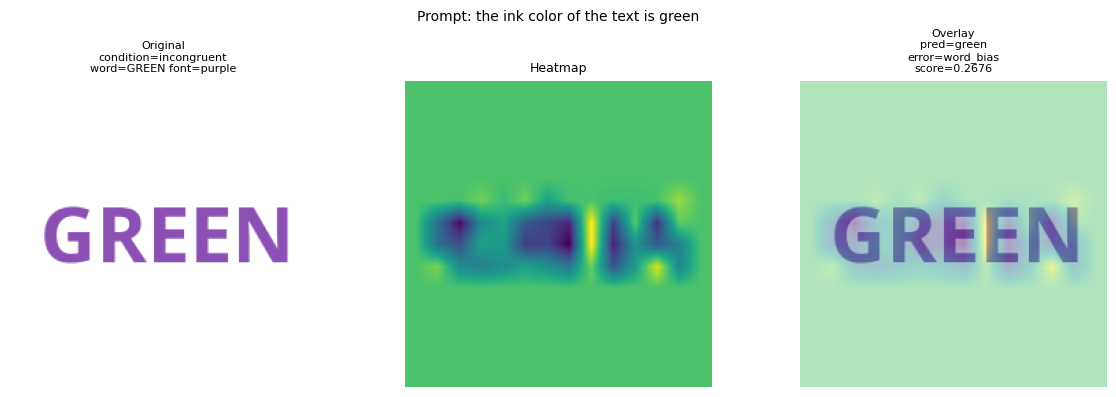

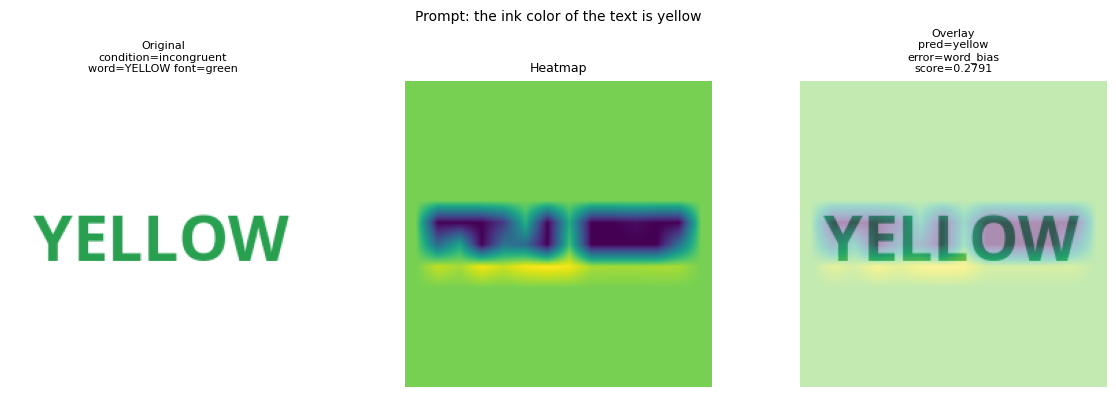

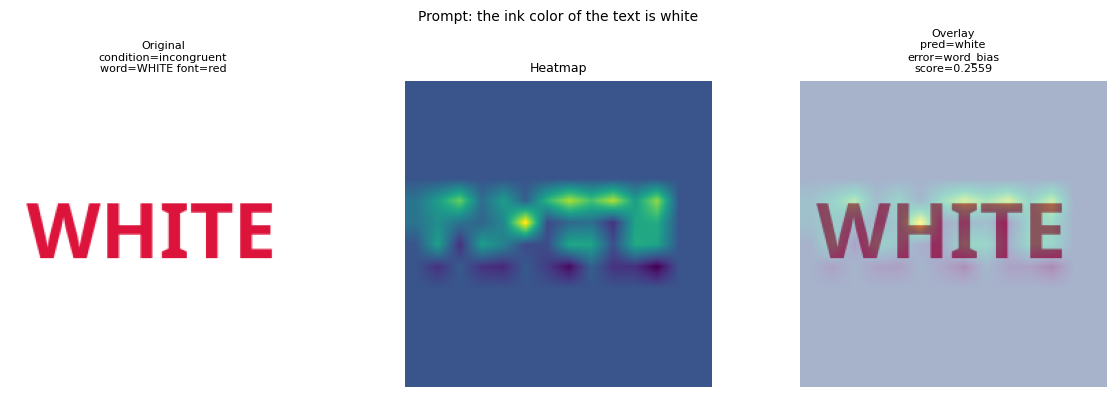

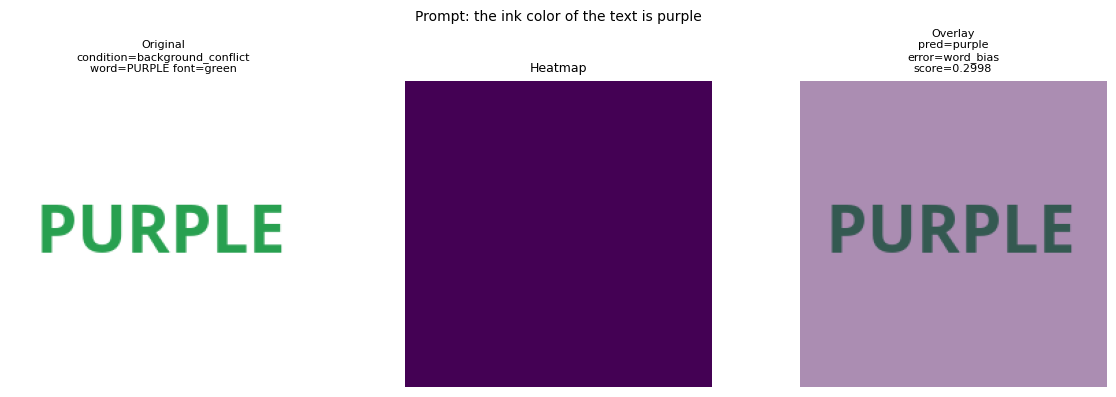

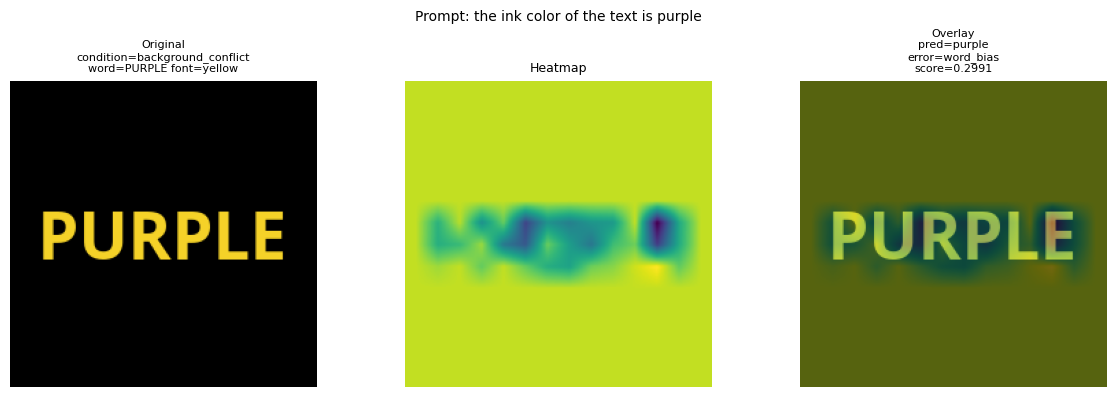

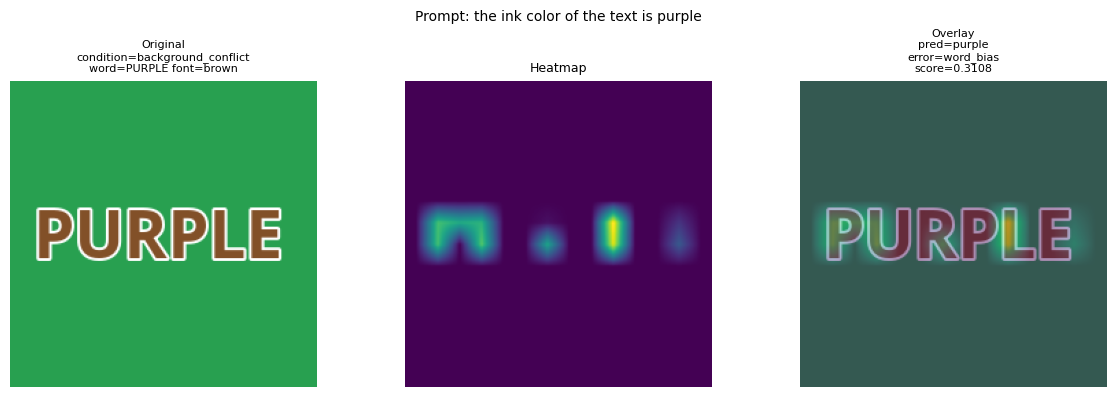

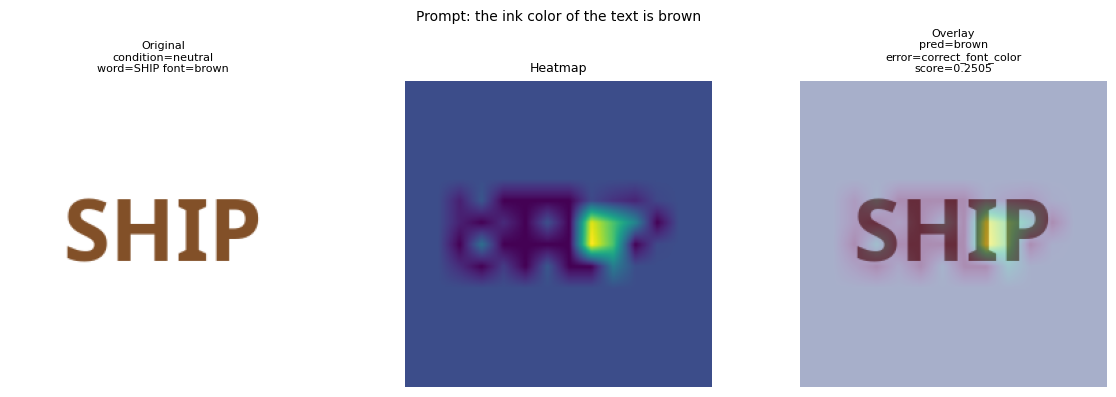

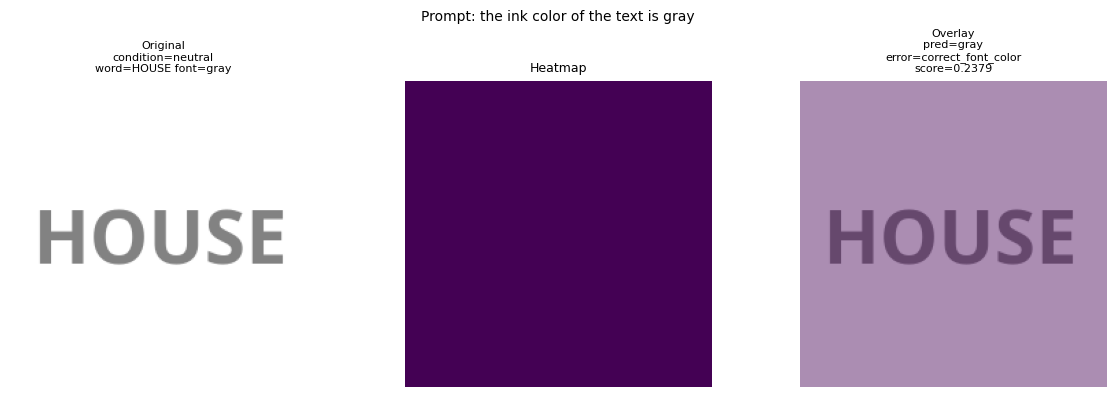

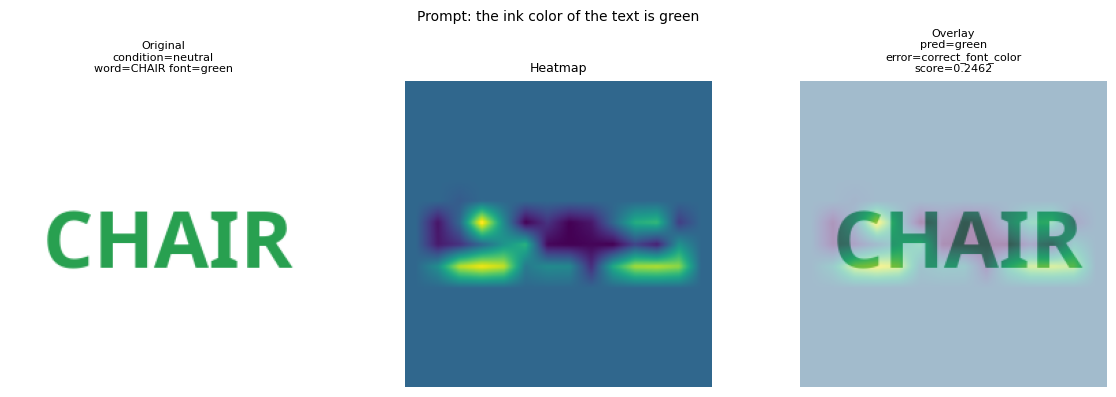

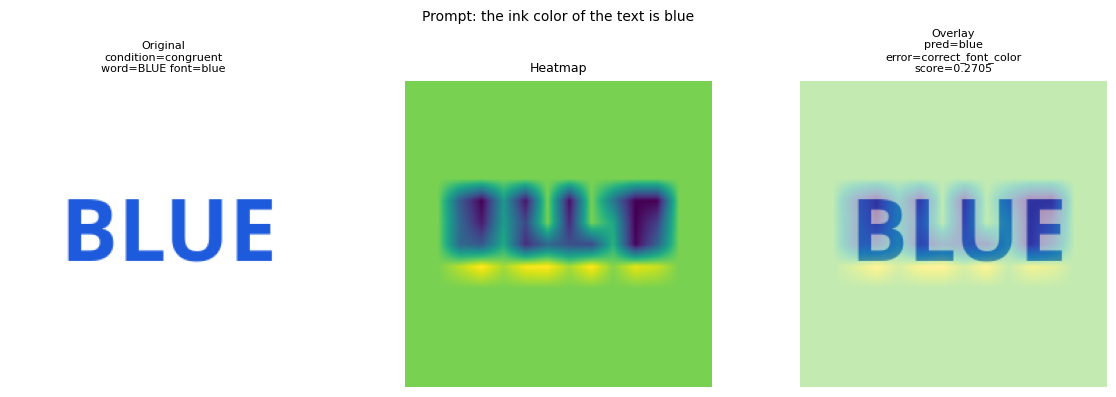

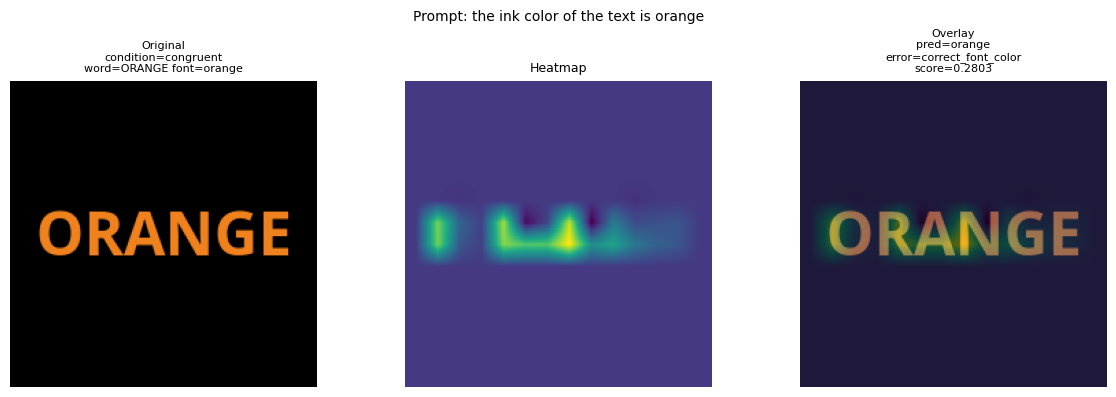

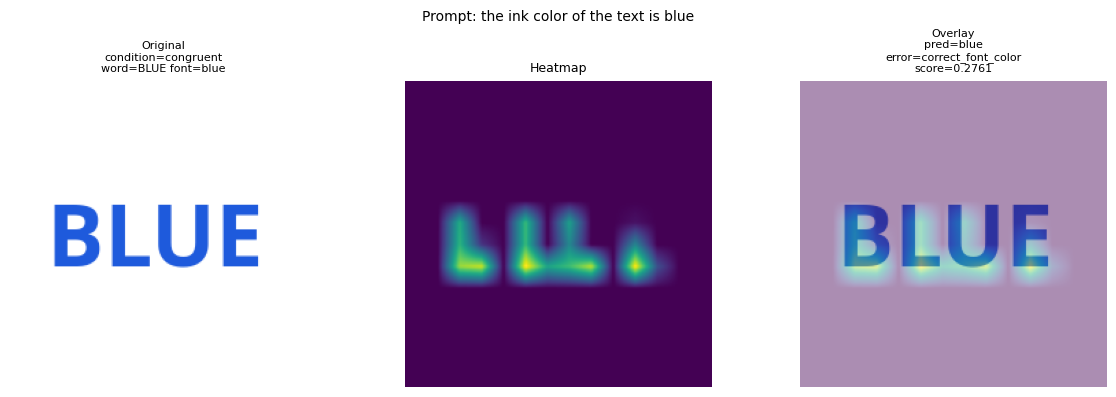

Saved: /content/stroop_multilingual_full_benchmark/results/experiment_6_clip_whitebox_heatmaps/decision_heatmap_metrics.csv


,image_id,image_path,mask_path,dataset,language,condition,word,word_color,font_color,background_color,...,is_correct,whitebox_group,whitebox_prompt,whitebox_score,heatmap_path,text_energy_share,background_energy_share,text_area_share,background_area_share,text_enrichment
0,main_english_stroop_english_incongruent_000677,/content/stroop_multilingual_full_benchmark/da...,/content/stroop_multilingual_full_benchmark/da...,stroop,english,incongruent,GREEN,green,purple,white,...,False,incongruent_word_bias,the ink color of the text is green,0.267578,/content/stroop_multilingual_full_benchmark/re...,0.083101,0.916899,0.122489,0.877511,0.678439
1,main_english_stroop_english_incongruent_007038,/content/stroop_multilingual_full_benchmark/da...,/content/stroop_multilingual_full_benchmark/da...,stroop,english,incongruent,YELLOW,yellow,green,white,...,False,incongruent_word_bias,the ink color of the text is yellow,0.279053,/content/stroop_multilingual_full_benchmark/re...,0.040595,0.959405,0.098374,0.901626,0.412659
2,main_english_stroop_english_incongruent_003398,/content/stroop_multilingual_full_benchmark/da...,/content/stroop_multilingual_full_benchmark/da...,stroop,english,incongruent,WHITE,white,red,white,...,False,incongruent_word_bias,the ink color of the text is white,0.255859,/content/stroop_multilingual_full_benchmark/re...,0.174411,0.825589,0.114995,0.885005,1.516680
3,main_english_stroop_english_background_conflic...,/content/stroop_multilingual_full_benchmark/da...,/content/stroop_multilingual_full_benchmark/da...,stroop,english,background_conflict,PURPLE,purple,green,white,...,False,background_conflict_word_bias,the ink color of the text is purple,0.299805,/content/stroop_multilingual_full_benchmark/re...,0.000000,0.000000,0.101204,0.898796,0.000000
4,main_english_stroop_english_background_conflic...,/content/stroop_multilingual_full_benchmark/da...,/content/stroop_multilingual_full_benchmark/da...,stroop,english,background_conflict,PURPLE,purple,yellow,black,...,False,background_conflict_word_bias,the ink color of the text is purple,0.299072,/content/stroop_multilingual_full_benchmark/re...,0.070646,0.929354,0.101204,0.898796,0.698060


In [25]:
# ============================================================
# Experiment 6: CLIP Grad-CAM-style heatmaps
# ============================================================

WHITEBOX_RESULTS_DIR = RESULTS_DIR / "experiment_6_clip_whitebox_heatmaps"
WHITEBOX_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

WHITEBOX_PROMPT_KEY = "exact_ink_color"

class CLIPConv1GradCAM:
    """
    Grad-CAM-style attribution for OpenAI CLIP.

    This hooks CLIP's visual.conv1 layer.
    For ViT-B/16, this usually gives a 14 x 14 patch grid.
    """

    def __init__(self, model):
        self.model = model
        self.activations = None
        self.gradients = None

        self.forward_handle = self.model.visual.conv1.register_forward_hook(
            self._save_activations
        )
        self.backward_handle = self.model.visual.conv1.register_full_backward_hook(
            self._save_gradients
        )

    def _save_activations(self, module, inputs, output):
        self.activations = output

    def _save_gradients(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def remove_hooks(self):
        self.forward_handle.remove()
        self.backward_handle.remove()

    def generate(self, image_path: str, text_prompt: str):
        self.model.zero_grad(set_to_none=True)

        image = Image.open(image_path).convert("RGB")
        image_tensor = clip_preprocess(image).unsqueeze(0).to(device)

        text_tokens = clip.tokenize([text_prompt]).to(device)

        with torch.no_grad():
            text_features = self.model.encode_text(text_tokens)
            text_features = text_features / text_features.norm(dim=-1, keepdim=True)

        image_features = self.model.encode_image(image_tensor)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)

        similarity_score = (image_features * text_features).sum()
        similarity_score.backward()

        activations = self.activations.detach()
        gradients = self.gradients.detach()

        weights = gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam)

        cam = torch.nn.functional.interpolate(
            cam,
            size=(IMAGE_SIZE, IMAGE_SIZE),
            mode="bilinear",
            align_corners=False,
        )

        cam = cam.squeeze().detach().float().cpu().numpy()

        if cam.max() > cam.min():
            cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        else:
            cam = np.zeros_like(cam)

        return cam, float(similarity_score.detach().cpu().item())


def compute_heatmap_mask_metrics(heatmap: np.ndarray, mask_path: str) -> Dict:
    mask = Image.open(mask_path).convert("L").resize((IMAGE_SIZE, IMAGE_SIZE))
    mask_arr = np.array(mask) > 0

    heatmap = np.array(heatmap, dtype=np.float32)
    total_energy = heatmap.sum() + 1e-8

    text_energy_share = float(heatmap[mask_arr].sum() / total_energy)
    background_energy_share = float(heatmap[~mask_arr].sum() / total_energy)
    text_area_share = float(mask_arr.mean())
    background_area_share = 1.0 - text_area_share
    text_enrichment = float(text_energy_share / (text_area_share + 1e-8))

    return {
        "text_energy_share": text_energy_share,
        "background_energy_share": background_energy_share,
        "text_area_share": text_area_share,
        "background_area_share": background_area_share,
        "text_enrichment": text_enrichment,
    }


def select_whitebox_examples(
    pred_df: pd.DataFrame,
    prompt_key: str,
    n_per_group: int,
) -> pd.DataFrame:
    base = pred_df[pred_df["prompt_key"] == prompt_key].copy()

    rules = [
        ("incongruent_word_bias", "incongruent", "word_bias"),
        ("background_conflict_word_bias", "background_conflict", "word_bias"),
        ("neutral_correct", "neutral", "correct_font_color"),
        ("congruent_correct", "congruent", "correct_font_color"),
    ]

    selected = []

    for group_name, condition, error_type in rules:
        subset = base[
            (base["condition"] == condition) &
            (base["error_type"] == error_type)
        ]

        if len(subset) == 0:
            print("No examples found for:", group_name)
            continue

        sample = subset.sample(
            n=min(n_per_group, len(subset)),
            random_state=SEED,
        ).copy()

        sample["whitebox_group"] = group_name
        selected.append(sample)

        print(f"{group_name}: selected {len(sample)} examples")

    if len(selected) == 0:
        raise ValueError("No white-box examples found.")

    return pd.concat(selected, ignore_index=True)


def save_heatmap_figure(row, heatmap, text_prompt, similarity_score, save_path):
    image = Image.open(row["image_path"]).convert("RGB")

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    axes[0].imshow(image)
    axes[0].set_title(
        f"Original\ncondition={row['condition']}\nword={row['word']} font={row['font_color']}",
        fontsize=8,
    )
    axes[0].axis("off")

    axes[1].imshow(heatmap)
    axes[1].set_title("Heatmap", fontsize=9)
    axes[1].axis("off")

    axes[2].imshow(image)
    axes[2].imshow(heatmap, alpha=0.45)
    axes[2].set_title(
        f"Overlay\npred={row['pred_color']}\nerror={row['error_type']}\nscore={similarity_score:.4f}",
        fontsize=8,
    )
    axes[2].axis("off")

    fig.suptitle(f"Prompt: {text_prompt}", fontsize=10)
    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)


if RUN_CLIP_EVAL:
    # Use prompt robustness results if already available.
    if "prompt_results_df" not in globals():
        prompt_results_df = pd.read_csv(PROMPT_RESULTS_DIR / "clip_prompt_robustness_predictions.csv")

    whitebox_examples_df = select_whitebox_examples(
        pred_df=prompt_results_df,
        prompt_key=WHITEBOX_PROMPT_KEY,
        n_per_group=WHITEBOX_N_PER_GROUP,
    )

    display(whitebox_examples_df[
        ["whitebox_group", "condition", "word", "font_color", "background_color", "pred_color", "error_type"]
    ])

    gradcam = CLIPConv1GradCAM(clip_model)

    decision_records = []

    for i, row in tqdm(
        whitebox_examples_df.iterrows(),
        total=len(whitebox_examples_df),
        desc="Generating CLIP decision heatmaps"
    ):
        pred_color = row["pred_color"]
        template = PROMPT_TEMPLATES[WHITEBOX_PROMPT_KEY]["template"]
        text_prompt = template.format(color=pred_color)

        heatmap, score = gradcam.generate(row["image_path"], text_prompt)
        metrics = compute_heatmap_mask_metrics(heatmap, row["mask_path"])

        save_name = (
            f"decision_{i:03d}_{row['whitebox_group']}_"
            f"word-{row['word']}_font-{row['font_color']}_pred-{pred_color}.png"
        ).replace("/", "_")
        save_path = WHITEBOX_RESULTS_DIR / save_name

        save_heatmap_figure(row, heatmap, text_prompt, score, save_path)

        record = row.to_dict()
        record["whitebox_prompt"] = text_prompt
        record["whitebox_score"] = score
        record["heatmap_path"] = str(save_path)
        record.update(metrics)
        decision_records.append(record)

    gradcam.remove_hooks()

    decision_heatmaps_df = pd.DataFrame(decision_records)
    decision_metrics_path = WHITEBOX_RESULTS_DIR / "decision_heatmap_metrics.csv"
    decision_heatmaps_df.to_csv(decision_metrics_path, index=False)

    print("Saved:", decision_metrics_path)
    display(decision_heatmaps_df.head())

# Optional Qwen attention heatmaps

Qwen heatmaps are not the same as CLIP Grad-CAM heatmaps.

For CLIP:

- heatmap = gradient-based image-text similarity attribution

For Qwen:

- heatmap = attention from generated answer tokens to image tokens

So in the report/meeting, describe this as:

**Qwen attention-based visual token heatmaps**

not as Grad-CAM.

In [26]:
# ============================================================
# Optional: Qwen attention-based heatmaps
# ============================================================
# This section assumes RUN_QWEN_EVAL=True and qwen_results_df exists.
# It reloads Qwen with eager attention because output_attentions=True may require it.

if RUN_QWEN_EVAL and "qwen_results_df" in globals():
    QWEN_HEATMAP_DIR = RESULTS_DIR / "experiment_6_qwen_attention_heatmaps"
    QWEN_HEATMAP_DIR.mkdir(parents=True, exist_ok=True)

    # Reload Qwen with eager attention for attentions.
    try:
        del qwen_model
        gc.collect()
        torch.cuda.empty_cache()
    except Exception:
        pass

    qwen_model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
        QWEN_MODEL_ID,
        torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
        device_map="auto",
        attn_implementation="eager",
    )
    qwen_processor = AutoProcessor.from_pretrained(QWEN_MODEL_ID)
    qwen_model.eval()

    def select_qwen_heatmap_examples(qwen_results_df, n_per_group=2):
        rules = [
            ("incongruent_word_bias", "incongruent", "word_bias"),
            ("background_conflict_word_bias", "background_conflict", "word_bias"),
            ("neutral_correct", "neutral", "correct_font_color"),
            ("congruent_correct", "congruent", "correct_font_color"),
        ]

        selected = []

        for group_name, condition, error_type in rules:
            subset = qwen_results_df[
                (qwen_results_df["condition"] == condition) &
                (qwen_results_df["error_type"] == error_type)
            ]

            if len(subset) == 0:
                print("No Qwen examples found for:", group_name)
                continue

            sample = subset.sample(
                n=min(n_per_group, len(subset)),
                random_state=SEED,
            ).copy()

            sample["qwen_heatmap_group"] = group_name
            selected.append(sample)

        if len(selected) == 0:
            raise ValueError("No Qwen heatmap examples found.")

        return pd.concat(selected, ignore_index=True)

    # Full Qwen attention heatmap extraction is architecture-sensitive.
    # Use this selected dataframe first; then inspect output_attentions shapes
    # before running a large heatmap batch.
    qwen_heatmap_examples_df = select_qwen_heatmap_examples(qwen_results_df, n_per_group=2)

    display(qwen_heatmap_examples_df[
        ["qwen_heatmap_group", "language", "condition", "word", "font_color", "background_color", "pred_color", "error_type"]
    ])

    print("Qwen heatmap examples selected.")
    print("Next step: use attention from generated answer tokens to visual tokens.")

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

,qwen_heatmap_group,language,condition,word,font_color,background_color,pred_color,error_type
0,incongruent_word_bias,english,incongruent,BROWN,red,white,brown,word_bias
1,incongruent_word_bias,chinese,incongruent,棕色,white,black,brown,word_bias
2,background_conflict_word_bias,chinese,background_conflict,灰色,brown,green,gray,word_bias
3,background_conflict_word_bias,chinese,background_conflict,黑色,white,brown,black,word_bias
4,neutral_correct,english,neutral,CAT,white,black,white,correct_font_color
5,neutral_correct,english,neutral,CHAIR,blue,white,blue,correct_font_color
6,congruent_correct,chinese,congruent,灰色,gray,white,gray,correct_font_color
7,congruent_correct,english,congruent,BLACK,black,white,black,correct_font_color


Qwen heatmap examples selected.
Next step: use attention from generated answer tokens to visual tokens.


In [27]:
# ============================================================
# Generate actual Qwen attention heatmaps
# Run this AFTER qwen_heatmap_examples_df has been created
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import pandas as pd
from tqdm.auto import tqdm
from pathlib import Path
from IPython.display import display, Image as IPyImage

QWEN_HEATMAP_DIR = RESULTS_DIR / "experiment_6_qwen_attention_heatmaps"
QWEN_HEATMAP_DIR.mkdir(parents=True, exist_ok=True)

print("Qwen heatmaps will be saved to:", QWEN_HEATMAP_DIR)


def normalize_heatmap(heatmap):
    heatmap = np.array(heatmap, dtype=np.float32)

    if heatmap.max() > heatmap.min():
        heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)
    else:
        heatmap = np.zeros_like(heatmap)

    return heatmap


def resize_heatmap_to_image(heatmap_2d, image_size=224):
    heatmap_tensor = torch.tensor(heatmap_2d, dtype=torch.float32)

    heatmap_resized = torch.nn.functional.interpolate(
        heatmap_tensor.unsqueeze(0).unsqueeze(0),
        size=(image_size, image_size),
        mode="bilinear",
        align_corners=False
    ).squeeze()

    return normalize_heatmap(heatmap_resized.cpu().numpy())


def qwen_attention_vector_to_2d(attn_vector, inputs):
    """
    Convert Qwen visual-token attention vector into a 2D heatmap.
    """

    attn_vector = np.array(attn_vector, dtype=np.float32)
    n_tokens = len(attn_vector)

    if "image_grid_thw" in inputs:
        grid_t, grid_h, grid_w = inputs["image_grid_thw"][0].detach().cpu().tolist()

        vision_config = getattr(qwen_model.config, "vision_config", None)
        merge_size = getattr(vision_config, "spatial_merge_size", 1)

        heat_h = max(1, int(grid_h // merge_size))
        heat_w = max(1, int(grid_w // merge_size))

        expected_tokens = int(grid_t * heat_h * heat_w)

        if expected_tokens == n_tokens:
            heatmap = attn_vector.reshape(int(grid_t), heat_h, heat_w).mean(axis=0)
            return heatmap

        if int(grid_h * grid_w) == n_tokens:
            heatmap = attn_vector.reshape(int(grid_h), int(grid_w))
            return heatmap

    # Fallback if Qwen token count does not exactly match image_grid_thw
    side = int(np.sqrt(n_tokens))

    if side * side == n_tokens:
        return attn_vector.reshape(side, side)

    height = max(1, side)
    width = int(np.ceil(n_tokens / height))

    padded = np.zeros(height * width, dtype=np.float32)
    padded[:n_tokens] = attn_vector

    return padded.reshape(height, width)


def make_qwen_color_question(image_path):
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image_path},
                {"type": "text", "text": VLM_COLOR_QUESTION},
            ],
        }
    ]

    return messages


def make_qwen_messages_with_answer(image_path, answer_text):
    messages = make_qwen_color_question(image_path)

    messages.append(
        {
            "role": "assistant",
            "content": [
                {"type": "text", "text": answer_text}
            ],
        }
    )

    return messages


def generate_qwen_attention_heatmap(row):
    """
    Generate one Qwen attention heatmap.

    This measures attention from generated answer tokens
    to image tokens.
    """

    image_path = row["image_path"]

    pred_color = str(row.get("pred_color", "")).lower().strip()

    if pred_color not in COLOR_NAMES:
        raw_answer = str(row.get("raw_answer", "")).lower()
        pred_color = parse_color_answer(raw_answer)

    if pred_color not in COLOR_NAMES:
        raise ValueError(f"Invalid pred_color: {pred_color}")

    # Prefix: image + question + assistant generation marker
    prefix_messages = make_qwen_color_question(image_path)

    prefix_text = qwen_processor.apply_chat_template(
        prefix_messages,
        tokenize=False,
        add_generation_prompt=True
    )

    prefix_image_inputs, prefix_video_inputs = process_vision_info(prefix_messages)

    prefix_inputs = qwen_processor(
        text=[prefix_text],
        images=prefix_image_inputs,
        videos=prefix_video_inputs,
        padding=True,
        return_tensors="pt"
    )

    # Full input: image + question + predicted answer
    full_messages = make_qwen_messages_with_answer(image_path, pred_color)

    full_text = qwen_processor.apply_chat_template(
        full_messages,
        tokenize=False,
        add_generation_prompt=False
    )

    full_image_inputs, full_video_inputs = process_vision_info(full_messages)

    full_inputs = qwen_processor(
        text=[full_text],
        images=full_image_inputs,
        videos=full_video_inputs,
        padding=True,
        return_tensors="pt"
    )

    qwen_device = next(qwen_model.parameters()).device

    prefix_inputs = prefix_inputs.to(qwen_device)
    full_inputs = full_inputs.to(qwen_device)

    prefix_len = int(prefix_inputs["attention_mask"][0].sum().item())
    full_len = int(full_inputs["attention_mask"][0].sum().item())

    answer_positions = torch.arange(prefix_len, full_len, device=qwen_device)

    input_ids = full_inputs["input_ids"][0]
    tokenizer = qwen_processor.tokenizer

    image_pad_id = tokenizer.convert_tokens_to_ids("<|image_pad|>")
    vision_start_id = tokenizer.convert_tokens_to_ids("<|vision_start|>")
    vision_end_id = tokenizer.convert_tokens_to_ids("<|vision_end|>")

    image_positions = (input_ids == image_pad_id).nonzero(as_tuple=True)[0]

    # Fallback: tokens between vision_start and vision_end
    if len(image_positions) == 0:
        vision_start_positions = (input_ids == vision_start_id).nonzero(as_tuple=True)[0]
        vision_end_positions = (input_ids == vision_end_id).nonzero(as_tuple=True)[0]

        if len(vision_start_positions) > 0 and len(vision_end_positions) > 0:
            start = int(vision_start_positions[0].item()) + 1
            end = int(vision_end_positions[0].item())
            image_positions = torch.arange(start, end, device=qwen_device)

    if len(image_positions) == 0:
        raise ValueError("Could not find Qwen image token positions.")

    with torch.no_grad():
        outputs = qwen_model(
            **full_inputs,
            output_attentions=True,
            return_dict=True,
            use_cache=False
        )

    if outputs.attentions is None:
        raise RuntimeError(
            "Qwen did not return attentions. Make sure the model was loaded with attn_implementation='eager'."
        )

    last_attn = outputs.attentions[-1]

    # Attention shape is usually:
    # [batch, heads, query_tokens, key_tokens]
    answer_to_image = last_attn[0, :, answer_positions, :][:, :, image_positions]

    # Average over heads and answer tokens
    image_attn_vector = answer_to_image.mean(dim=(0, 1)).detach().float().cpu().numpy()

    heatmap_2d = qwen_attention_vector_to_2d(image_attn_vector, full_inputs)
    heatmap_full = resize_heatmap_to_image(heatmap_2d, image_size=IMAGE_SIZE)

    info = {
        "pred_color": pred_color,
        "answer_token_count": int(len(answer_positions)),
        "image_token_count": int(len(image_positions)),
    }

    return heatmap_full, info


def save_qwen_heatmap_figure(row, heatmap, info, save_path):
    image = Image.open(row["image_path"]).convert("RGB")

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    axes[0].imshow(image)
    axes[0].set_title(
        f"Original\nlang={row['language']} condition={row['condition']}\n"
        f"word={row['word']} font={row['font_color']} bg={row['background_color']}",
        fontsize=8
    )
    axes[0].axis("off")

    axes[1].imshow(heatmap)
    axes[1].set_title("Qwen attention heatmap", fontsize=9)
    axes[1].axis("off")

    axes[2].imshow(image)
    axes[2].imshow(heatmap, alpha=0.45)
    axes[2].set_title(
        f"Overlay\npred={info['pred_color']}\nerror={row.get('error_type', 'unknown')}",
        fontsize=8
    )
    axes[2].axis("off")

    fig.suptitle(
        "Qwen2.5-VL attention from answer tokens to image tokens",
        fontsize=10
    )

    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)

Qwen heatmaps will be saved to: /content/stroop_multilingual_full_benchmark/results/experiment_6_qwen_attention_heatmaps


Generating Qwen attention heatmaps:   0%|          | 0/8 [00:00<?, ?it/s]

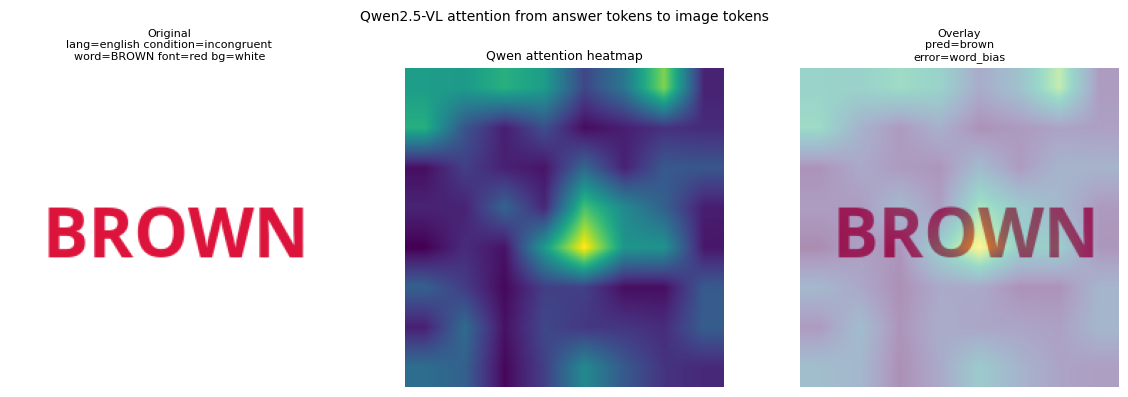

/tmp/ipykernel_794/1378085477.py:269: UserWarning: Glyph 26837 (\N{CJK UNIFIED IDEOGRAPH-68D5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_794/1378085477.py:269: UserWarning: Glyph 33394 (\N{CJK UNIFIED IDEOGRAPH-8272}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_794/1378085477.py:270: UserWarning: Glyph 26837 (\N{CJK UNIFIED IDEOGRAPH-68D5}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=200, bbox_inches="tight")
/tmp/ipykernel_794/1378085477.py:270: UserWarning: Glyph 33394 (\N{CJK UNIFIED IDEOGRAPH-8272}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=200, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 26837 (\N{CJK UNIFIED IDEOGRAPH-68D5}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 33394 (\N{CJK UNIFIED IDEOGRAPH

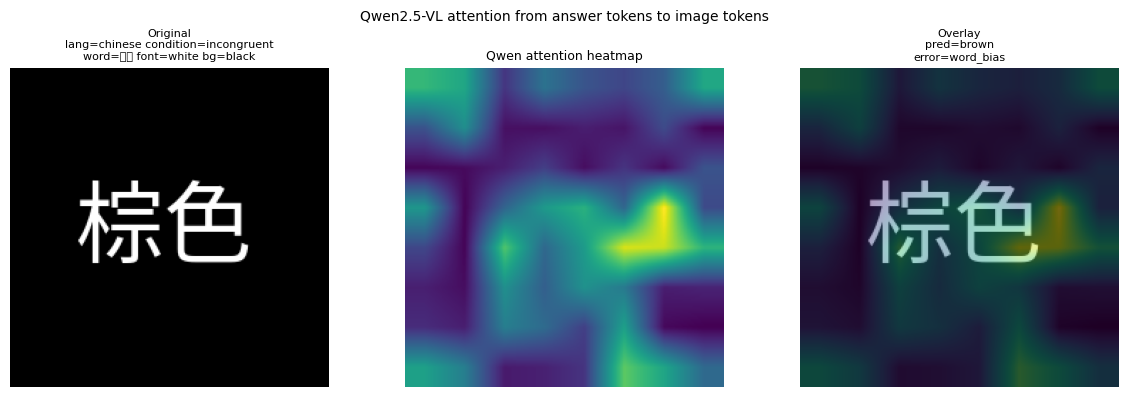

/tmp/ipykernel_794/1378085477.py:269: UserWarning: Glyph 28784 (\N{CJK UNIFIED IDEOGRAPH-7070}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_794/1378085477.py:270: UserWarning: Glyph 28784 (\N{CJK UNIFIED IDEOGRAPH-7070}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=200, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 28784 (\N{CJK UNIFIED IDEOGRAPH-7070}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


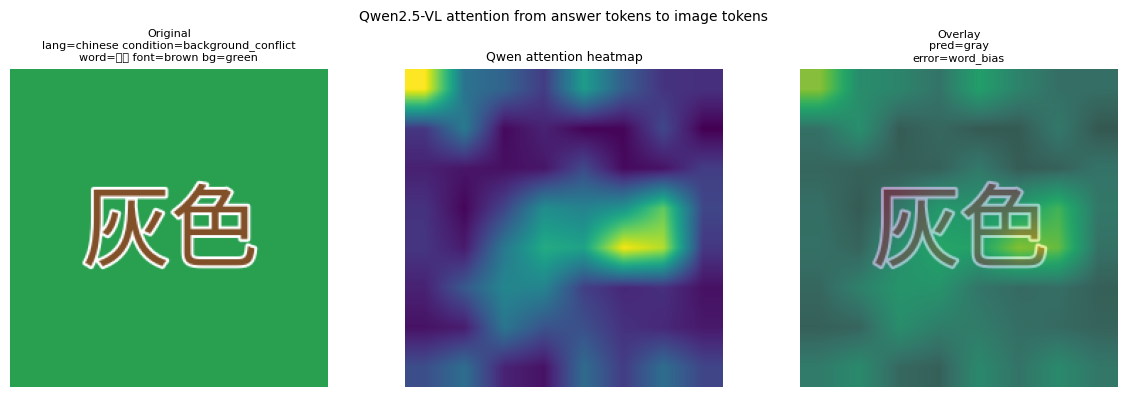

/tmp/ipykernel_794/1378085477.py:269: UserWarning: Glyph 40657 (\N{CJK UNIFIED IDEOGRAPH-9ED1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_794/1378085477.py:270: UserWarning: Glyph 40657 (\N{CJK UNIFIED IDEOGRAPH-9ED1}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=200, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 40657 (\N{CJK UNIFIED IDEOGRAPH-9ED1}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


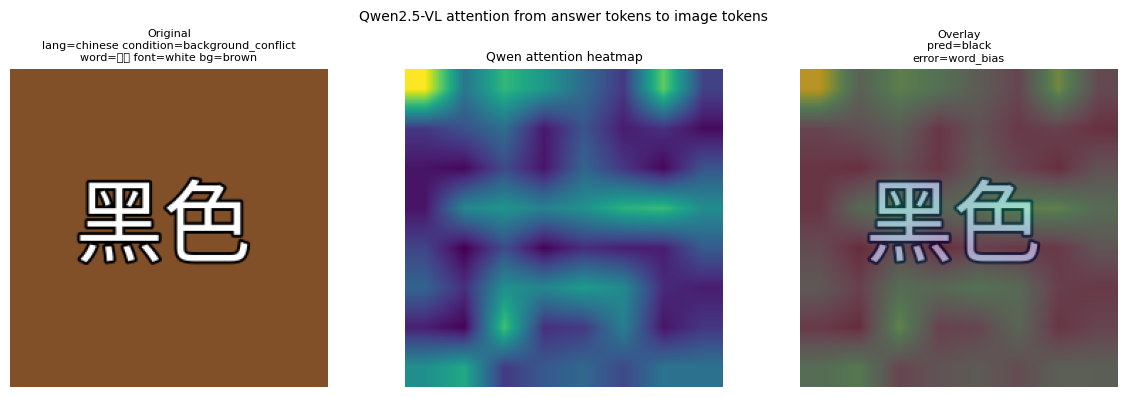

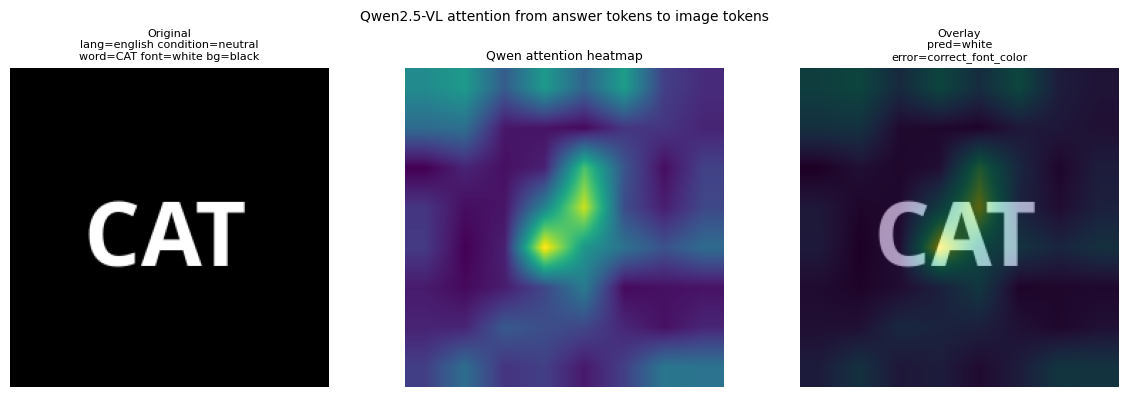

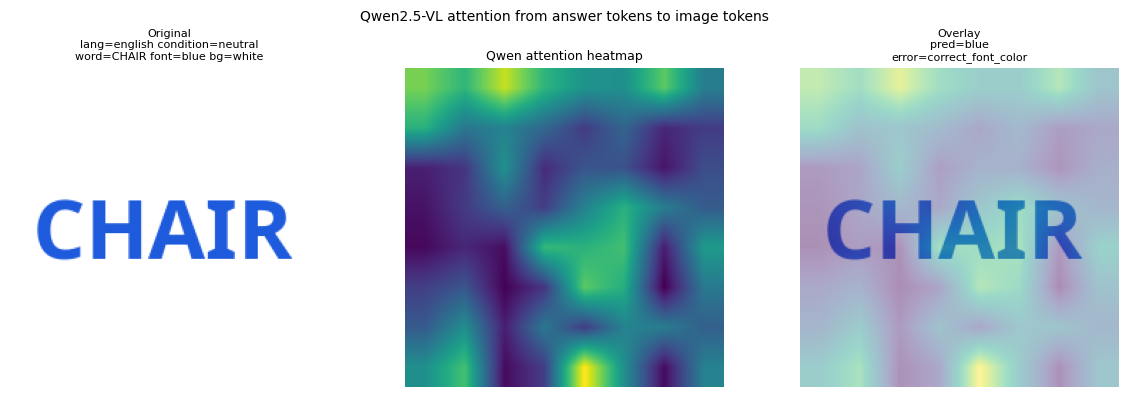

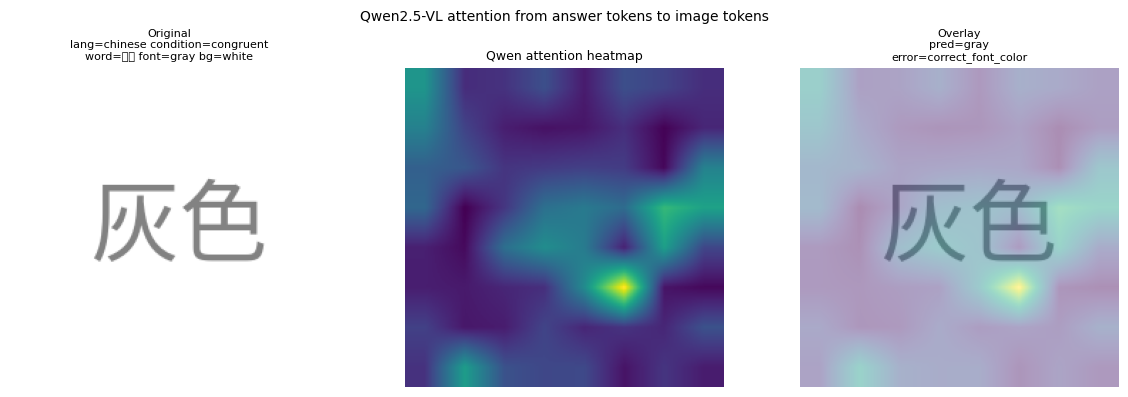

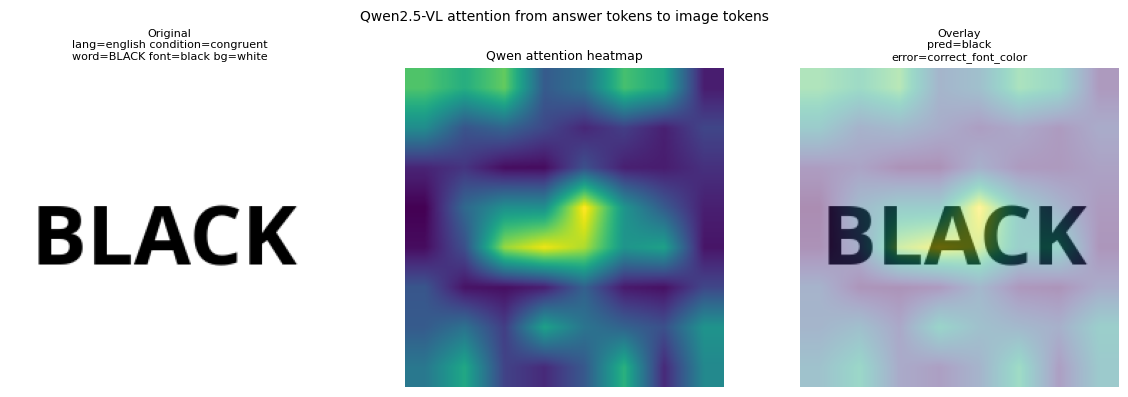

Saved Qwen heatmap records: /content/stroop_multilingual_full_benchmark/results/experiment_6_qwen_attention_heatmaps/qwen_attention_heatmap_records.csv


,image_id,image_path,mask_path,dataset,language,condition,word,word_color,font_color,background_color,...,dataset_name,model_name,raw_answer,pred_color,error_type,is_correct,qwen_heatmap_group,answer_token_count,image_token_count,qwen_heatmap_path
0,multilingual_stroop_english_incongruent_001831,/content/stroop_multilingual_full_benchmark/da...,/content/stroop_multilingual_full_benchmark/da...,stroop,english,incongruent,BROWN,brown,red,white,...,multilingual_stroop,Qwen/Qwen2.5-VL-3B-Instruct,brown,brown,word_bias,False,incongruent_word_bias,3,64,/content/stroop_multilingual_full_benchmark/re...
1,multilingual_stroop_chinese_incongruent_001049,/content/stroop_multilingual_full_benchmark/da...,/content/stroop_multilingual_full_benchmark/da...,stroop,chinese,incongruent,棕色,brown,white,black,...,multilingual_stroop,Qwen/Qwen2.5-VL-3B-Instruct,brown,brown,word_bias,False,incongruent_word_bias,3,64,/content/stroop_multilingual_full_benchmark/re...
2,multilingual_stroop_chinese_background_conflic...,/content/stroop_multilingual_full_benchmark/da...,/content/stroop_multilingual_full_benchmark/da...,stroop,chinese,background_conflict,灰色,gray,brown,green,...,multilingual_stroop,Qwen/Qwen2.5-VL-3B-Instruct,gray,gray,word_bias,False,background_conflict_word_bias,3,64,/content/stroop_multilingual_full_benchmark/re...
3,multilingual_stroop_chinese_background_conflic...,/content/stroop_multilingual_full_benchmark/da...,/content/stroop_multilingual_full_benchmark/da...,stroop,chinese,background_conflict,黑色,black,white,brown,...,multilingual_stroop,Qwen/Qwen2.5-VL-3B-Instruct,black,black,word_bias,False,background_conflict_word_bias,3,64,/content/stroop_multilingual_full_benchmark/re...
4,multilingual_stroop_english_neutral_003044,/content/stroop_multilingual_full_benchmark/da...,/content/stroop_multilingual_full_benchmark/da...,stroop,english,neutral,CAT,,white,black,...,multilingual_stroop,Qwen/Qwen2.5-VL-3B-Instruct,white,white,correct_font_color,True,neutral_correct,3,64,/content/stroop_multilingual_full_benchmark/re...
5,multilingual_stroop_english_neutral_000720,/content/stroop_multilingual_full_benchmark/da...,/content/stroop_multilingual_full_benchmark/da...,stroop,english,neutral,CHAIR,,blue,white,...,multilingual_stroop,Qwen/Qwen2.5-VL-3B-Instruct,blue,blue,correct_font_color,True,neutral_correct,3,64,/content/stroop_multilingual_full_benchmark/re...
6,multilingual_stroop_chinese_congruent_003550,/content/stroop_multilingual_full_benchmark/da...,/content/stroop_multilingual_full_benchmark/da...,stroop,chinese,congruent,灰色,gray,gray,white,...,multilingual_stroop,Qwen/Qwen2.5-VL-3B-Instruct,gray,gray,correct_font_color,True,congruent_correct,3,64,/content/stroop_multilingual_full_benchmark/re...
7,multilingual_stroop_english_congruent_001335,/content/stroop_multilingual_full_benchmark/da...,/content/stroop_multilingual_full_benchmark/da...,stroop,english,congruent,BLACK,black,black,white,...,multilingual_stroop,Qwen/Qwen2.5-VL-3B-Instruct,black,black,correct_font_color,True,congruent_correct,3,64,/content/stroop_multilingual_full_benchmark/re...


In [28]:
# ============================================================
# Run Qwen heatmap generation for selected examples
# ============================================================

qwen_heatmap_records = []

for i, row in tqdm(
    qwen_heatmap_examples_df.iterrows(),
    total=len(qwen_heatmap_examples_df),
    desc="Generating Qwen attention heatmaps"
):
    try:
        heatmap, info = generate_qwen_attention_heatmap(row)

        save_name = (
            f"qwen_{i:03d}_{row['qwen_heatmap_group']}_"
            f"{row['language']}_"
            f"word-{row['word']}_"
            f"font-{row['font_color']}_"
            f"pred-{info['pred_color']}.png"
        ).replace("/", "_").replace(" ", "_")

        save_path = QWEN_HEATMAP_DIR / save_name

        save_qwen_heatmap_figure(
            row=row,
            heatmap=heatmap,
            info=info,
            save_path=save_path
        )

        record = row.to_dict()
        record.update(info)
        record["qwen_heatmap_path"] = str(save_path)
        qwen_heatmap_records.append(record)

    except Exception as e:
        print("Failed for row:", i)
        print("Reason:", repr(e))

qwen_attention_heatmaps_df = pd.DataFrame(qwen_heatmap_records)

qwen_heatmap_csv_path = QWEN_HEATMAP_DIR / "qwen_attention_heatmap_records.csv"
qwen_attention_heatmaps_df.to_csv(qwen_heatmap_csv_path, index=False)

print("Saved Qwen heatmap records:", qwen_heatmap_csv_path)
display(qwen_attention_heatmaps_df)

# Dataset ledger and final summary

This cell saves a clear summary of every experiment, including how many images are used.

This is useful for your supervisor meeting and for the report methodology section.

In [30]:
# ============================================================
# Save dataset ledger and final experiment summary
# ============================================================

def create_dataset_ledger() -> pd.DataFrame:
    rows = []

    rows.append({
        "experiment": "Experiment 1: Main English Stroop",
        "dataset": "main_english_stroop",
        "languages": "English",
        "conditions_or_classes": "4 conditions: congruent, incongruent, neutral, background_conflict",
        "images_per_group": MAIN_NUM_PER_CONDITION,
        "unique_images": 4 * MAIN_NUM_PER_CONDITION,
        "evaluation_count": 4 * MAIN_NUM_PER_CONDITION,
        "purpose": "Test whether model follows visual font color or written English word meaning.",
    })

    rows.append({
        "experiment": "Experiment 2: Prompt robustness",
        "dataset": "main_english_stroop reused",
        "languages": "English",
        "conditions_or_classes": f"Same 4 Stroop conditions × {len(PROMPT_TEMPLATES)} prompt templates",
        "images_per_group": MAIN_NUM_PER_CONDITION,
        "unique_images": 4 * MAIN_NUM_PER_CONDITION,
        "evaluation_count": 4 * MAIN_NUM_PER_CONDITION * len(PROMPT_TEMPLATES),
        "purpose": "Test whether word bias changes across vague, exact, descriptive, and control prompts.",
    })

    rows.append({
        "experiment": "Experiment 3: Text-meaning recognition control",
        "dataset": "text_meaning_control",
        "languages": ", ".join(LANGUAGES),
        "conditions_or_classes": "20 word classes per language: 10 color words + 10 neutral object words",
        "images_per_group": TEXT_MEANING_SAMPLES_PER_WORD,
        "unique_images": len(LANGUAGES) * 20 * TEXT_MEANING_SAMPLES_PER_WORD,
        "evaluation_count": len(LANGUAGES) * 20 * TEXT_MEANING_SAMPLES_PER_WORD,
        "purpose": "Check whether model can recognize written words in a clean black-text condition.",
    })

    rows.append({
        "experiment": "Experiment 4: Multilingual Stroop",
        "dataset": "multilingual_stroop",
        "languages": ", ".join(LANGUAGES),
        "conditions_or_classes": "4 Stroop conditions per language",
        "images_per_group": MULTILINGUAL_NUM_PER_LANGUAGE_CONDITION,
        "unique_images": len(LANGUAGES) * len(CONDITIONS) * MULTILINGUAL_NUM_PER_LANGUAGE_CONDITION,
        "evaluation_count": len(LANGUAGES) * len(CONDITIONS) * MULTILINGUAL_NUM_PER_LANGUAGE_CONDITION,
        "purpose": "Test whether Stroop-like word bias changes across scripts.",
    })

    rows.append({
        "experiment": "Experiment 5: Qwen/Llama model comparison",
        "dataset": "balanced subset of multilingual_stroop",
        "languages": ", ".join(LANGUAGES),
        "conditions_or_classes": "4 Stroop conditions per language",
        "images_per_group": VLM_SUBSET_PER_LANGUAGE_CONDITION,
        "unique_images": len(LANGUAGES) * len(CONDITIONS) * VLM_SUBSET_PER_LANGUAGE_CONDITION,
        "evaluation_count": len(LANGUAGES) * len(CONDITIONS) * VLM_SUBSET_PER_LANGUAGE_CONDITION,
        "purpose": "Compare instruction-following VLMs on the same balanced benchmark.",
    })

    rows.append({
        "experiment": "Experiment 6: Heatmaps",
        "dataset": "selected examples from prediction results",
        "languages": "Usually English first; can extend to multilingual",
        "conditions_or_classes": "word-bias and correct representative examples",
        "images_per_group": WHITEBOX_N_PER_GROUP,
        "unique_images": "selected qualitative examples",
        "evaluation_count": "selected qualitative examples",
        "purpose": "Explain selected model decisions using CLIP Grad-CAM-style heatmaps and optional Qwen attention heatmaps.",
    })

    return pd.DataFrame(rows)


dataset_ledger_df = create_dataset_ledger()

ledger_path = RESULTS_DIR / "dataset_ledger.csv"
dataset_ledger_df.to_csv(ledger_path, index=False)

display(dataset_ledger_df)

summary_text = f"""
Expanded Stroop-VLM Benchmark Summary
====================================

Experiment scale: {EXPERIMENT_SCALE}

Experiment 1: Main English Stroop
---------------------------------
Images: {4 * MAIN_NUM_PER_CONDITION}
Breakdown:
- Congruent: {MAIN_NUM_PER_CONDITION}
- Incongruent: {MAIN_NUM_PER_CONDITION}
- Neutral: {MAIN_NUM_PER_CONDITION}
- Background-conflict: {MAIN_NUM_PER_CONDITION}

Experiment 2: Prompt Robustness
-------------------------------
Unique images: {4 * MAIN_NUM_PER_CONDITION}
Prompt templates: {len(PROMPT_TEMPLATES)}
Prompt evaluations: {4 * MAIN_NUM_PER_CONDITION * len(PROMPT_TEMPLATES)}

Prompt styles:
- vague
- ambiguous
- exact
- descriptive
- control

Experiment 3: Text-Meaning Recognition Control
----------------------------------------------
Images: {len(LANGUAGES) * 20 * TEXT_MEANING_SAMPLES_PER_WORD}
Languages: {", ".join(LANGUAGES)}
Words per language: 20
Samples per word: {TEXT_MEANING_SAMPLES_PER_WORD}
Setup: black text on white background

Experiment 4: Multilingual Stroop
---------------------------------
Images: {len(LANGUAGES) * len(CONDITIONS) * MULTILINGUAL_NUM_PER_LANGUAGE_CONDITION}
Languages: {", ".join(LANGUAGES)}
Conditions: {", ".join(CONDITIONS)}
Images per language-condition: {MULTILINGUAL_NUM_PER_LANGUAGE_CONDITION}

Experiment 5: Qwen/Llama Model Comparison
-----------------------------------------
Balanced subset per model: {len(LANGUAGES) * len(CONDITIONS) * VLM_SUBSET_PER_LANGUAGE_CONDITION}
Images per language-condition: {VLM_SUBSET_PER_LANGUAGE_CONDITION}

Experiment 6: Heatmaps
----------------------
CLIP: custom Grad-CAM-style heatmaps over visual patches.
Qwen: optional attention-based visual token heatmaps.
"""

summary_path = RESULTS_DIR / "expanded_experiment_summary.txt"
summary_path.write_text(summary_text)

print(summary_text)
print("Saved dataset ledger:", ledger_path)
print("Saved summary:", summary_path)

,experiment,dataset,languages,conditions_or_classes,images_per_group,unique_images,evaluation_count,purpose
0,Experiment 1: Main English Stroop,main_english_stroop,English,"4 conditions: congruent, incongruent, neutral,...",10000,40000,40000,Test whether model follows visual font color o...
1,Experiment 2: Prompt robustness,main_english_stroop reused,English,Same 4 Stroop conditions × 12 prompt templates,10000,40000,480000,"Test whether word bias changes across vague, e..."
2,Experiment 3: Text-meaning recognition control,text_meaning_control,"english, chinese, hindi, arabic",20 word classes per language: 10 color words +...,250,20000,20000,Check whether model can recognize written word...
3,Experiment 4: Multilingual Stroop,multilingual_stroop,"english, chinese, hindi, arabic",4 Stroop conditions per language,5000,80000,80000,Test whether Stroop-like word bias changes acr...
4,Experiment 5: Qwen/Llama model comparison,balanced subset of multilingual_stroop,"english, chinese, hindi, arabic",4 Stroop conditions per language,1000,16000,16000,Compare instruction-following VLMs on the same...
5,Experiment 6: Heatmaps,selected examples from prediction results,Usually English first; can extend to multilingual,word-bias and correct representative examples,3,selected qualitative examples,selected qualitative examples,Explain selected model decisions using CLIP Gr...



Expanded Stroop-VLM Benchmark Summary

Experiment scale: full

Experiment 1: Main English Stroop
---------------------------------
Images: 40000
Breakdown:
- Congruent: 10000
- Incongruent: 10000
- Neutral: 10000
- Background-conflict: 10000

Experiment 2: Prompt Robustness
-------------------------------
Unique images: 40000
Prompt templates: 12
Prompt evaluations: 480000

Prompt styles:
- vague
- ambiguous
- exact
- descriptive
- control

Experiment 3: Text-Meaning Recognition Control
----------------------------------------------
Images: 20000
Languages: english, chinese, hindi, arabic
Words per language: 20
Samples per word: 250
Setup: black text on white background

Experiment 4: Multilingual Stroop
---------------------------------
Images: 80000
Languages: english, chinese, hindi, arabic
Conditions: congruent, incongruent, neutral, background_conflict
Images per language-condition: 5000

Experiment 5: Qwen/Llama Model Comparison
-----------------------------------------
Balanced

# Save results to Google Drive

Run this after the experiments finish.

It copies the full results folder to your Google Drive.

In [31]:
# ============================================================
# Save results folder to Google Drive
# ============================================================

from google.colab import drive
import shutil
import datetime

drive.mount("/content/drive")

timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

drive_project_dir = Path("/content/drive/MyDrive/DissertationStroopEffect")
drive_project_dir.mkdir(parents=True, exist_ok=True)

destination_results_dir = drive_project_dir / f"ExpandedStroopResults_{timestamp}"

if RESULTS_DIR.exists():
    shutil.copytree(RESULTS_DIR, destination_results_dir)
    print("Results saved successfully to Google Drive:")
    print(destination_results_dir)
else:
    print("RESULTS_DIR not found:", RESULTS_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Results saved successfully to Google Drive:
/content/drive/MyDrive/DissertationStroopEffect/ExpandedStroopResults_20260811_205228


# Explanation

I expanded the previous Stroop experiment into a clearer benchmark with explicit dataset sizes for each experiment.

The main English Stroop dataset now has 40,000 images, with 10,000 images in each of the four conditions: congruent, incongruent, neutral, and background-conflict.

The prompt robustness experiment reuses the same 40,000 images, but evaluates them with multiple prompt styles: vague, ambiguous, exact, descriptive, and control prompts. This helps test whether word bias is reduced when the task instruction is made more explicit.

The text-meaning recognition control contains black text on a white background. It has four languages, 20 word classes per language, and 250 samples per word, giving 20,000 images. This experiment checks whether the model can read the word in a clean setting before we interpret Stroop interference.

The multilingual Stroop dataset has English, Chinese, Hindi, and Arabic. It uses four conditions and 5,000 images per language-condition, giving 80,000 images. The semantic color labels are the same across languages, but the written script changes. This tests whether word bias depends on script-level text understanding.

For model comparison, CLIP can be run on the full dataset. Qwen2.5-VL and Llama Vision are included as optional sections and should first be run on a balanced subset of 16,000 images per model.

For interpretability, CLIP uses custom Grad-CAM-style heatmaps, while Qwen uses attention-based visual token heatmaps. These should be described as different methods because the model architectures are different.